# 02_eda — 타깃(발전량) 탐색적 데이터 분석

**목적(Why)**: 이 프로젝트는 모델을 만들기 전에 데이터를 이해하는 것을 최우선으로 합니다 (CLAUDE.md 2장). 이 노트북에서는 가장 먼저 예측 대상인 `kpx_group_1/2/3` 발전량 자체를 들여다봅니다.

**입력**: `data/train/train_labels.csv` (1절), `data/processed/*.parquet` (2절부터 — `01_preprocessing.ipynb`가 만든 캐시), `data/train/scada_*.csv` (4·6절)
**출력**: 이 노트북의 그림·표 → 이후 `reports/02_eda.md`로 정리

체크리스트 진행 상황: 1~5절(타깃, 기상 예보, 타깃×기상 관계 심화, SCADA 심화, 시간 무결성) 완료, 6절(데이터 사이언티스트·도메인 전문가 관점 후속 검증)이 마지막 배치.

## 0. 환경 설정

이 셀은 라이브러리를 불러오고 경로·상수를 정하는 준비 셀입니다. 계산은 하지 않습니다.

In [1]:
import sys
print(sys.executable)  # venv 안의 파이썬을 쓰고 있는지 확인

c:\Users\cho03\Desktop\wind_forecast_new\venv\Scripts\python.exe


**확인할 것**: 경로에 `wind_forecast\venv`가 포함되어 있어야 합니다 (가상환경 커널을 쓰고 있다는 뜻).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 50)

SEED = 42
np.random.seed(SEED)

TRAIN_LABELS_PATH = "../data/train/train_labels.csv"
PROCESSED_DIR = "../data/processed"

CAPACITY_KWH = {
    "kpx_group_1": 21600,
    "kpx_group_2": 21600,
    "kpx_group_3": 21000,
}
GROUP_COLS = list(CAPACITY_KWH.keys())

## 1. 타깃(train_labels.csv) 탐색

### 1-1. 데이터 로드

원본 CSV를 그대로 불러와서 shape·컬럼·자료형을 확인합니다. `kst_dtm`을 시간 타입으로 바꿔서 이후 시계열 연산(월별 집계, 시간대별 평균 등)이 되도록 준비합니다.

In [3]:
labels = pd.read_csv(TRAIN_LABELS_PATH, encoding="utf-8-sig")
labels["kst_dtm"] = pd.to_datetime(labels["kst_dtm"])

print(labels.shape)
print(labels.dtypes)
labels.head(3)

(26304, 4)
kst_dtm        datetime64[us]
kpx_group_1           float64
kpx_group_2           float64
kpx_group_3           float64
dtype: object


,kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,2022-01-01 01:00:00,12004.421,9719.242,NaN
1,2022-01-01 02:00:00,12901.137,10297.768,NaN
2,2022-01-01 03:00:00,12091.200,10731.663,NaN


**확인할 것**
- shape이 `(26304, 4)`여야 합니다 (data_description.md 기준)
- `kst_dtm`이 `datetime64` 타입으로 바뀌었는지
- `kpx_group_3` 초반 값이 NaN(빈칸)인지 — 2022년엔 group_3 라벨이 없다고 문서에 적혀 있으므로

### 1-2. 그룹별 라벨 제공 기간 확인

data_description.md에는 group_1/2는 2022~2024년, group_3은 2023~2024년만 값이 있다고 적혀 있습니다. 문서와 실제 데이터가 다를 수도 있으니 항상 실데이터로 직접 확인합니다.

In [4]:
for col in GROUP_COLS:
    valid = labels.dropna(subset=[col])
    print(col, "->", valid["kst_dtm"].min(), "~", valid["kst_dtm"].max(), "| 유효 행 수:", len(valid))

kpx_group_1 -> 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 26200
kpx_group_2 -> 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 26201
kpx_group_3 -> 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 17538


**확인할 것**
- group_1, group_2는 2022-01-01부터 시작하는지
- group_3은 2023년 몇 월부터 시작하는지 (정확한 시작일)
- 유효 행 수 차이 — 이후 검증 B안(확장 윈도우 fold1)에서 group_3 학습 데이터가 얼마나 얕은지 가늠하는 근거가 됩니다

### 1-3. 발전량 분포 확인

무풍 시간대(0 근처)와 정격 근처(설비용량 부근) 두 군데에 값이 몰리는 '쌍봉 분포'를 예상합니다 — 파워커브(풍속-발전량 관계) 특성상 풍속이 컷인(cut-in, 터빈이 돌기 시작하는 최소 풍속) 이하면 0에 가깝고, 정격풍속 이상이면 설비용량 근처에서 평평해지기 때문입니다.

설비용량을 넘는 값이 있는지도 함께 봅니다 — 있다고 해서 무조건 삭제하지 않습니다. 실제 운영 데이터의 계측 여유율일 수 있어서, 먼저 얼마나·왜 넘는지부터 기록합니다(CLAUDE.md 2.4절, 출력제한/이상치는 지우지 않고 이해한다).

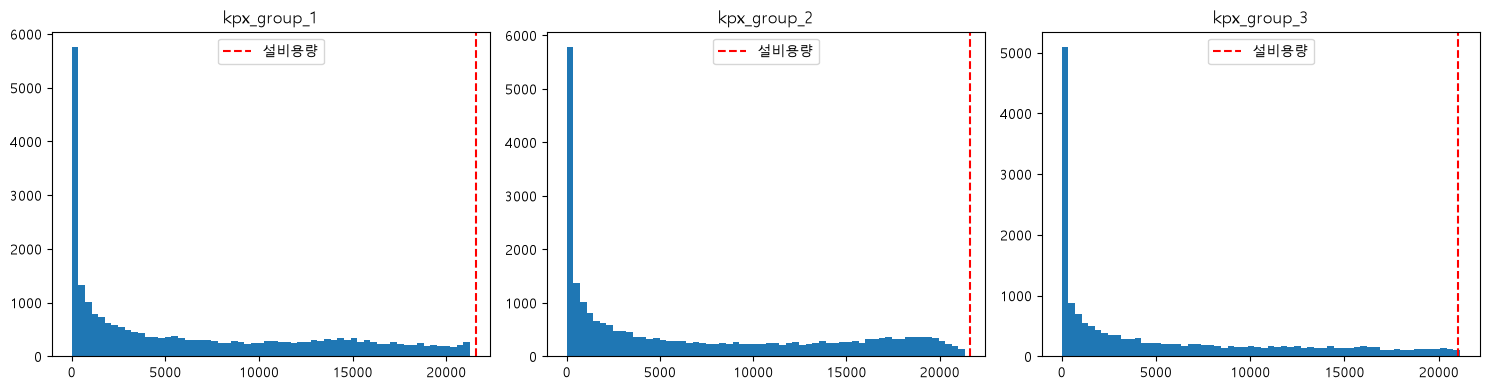

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, GROUP_COLS):
    data = labels[col].dropna()
    ax.hist(data, bins=60)
    ax.axvline(CAPACITY_KWH[col], color="red", linestyle="--", label="설비용량")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
for col in GROUP_COLS:
    data = labels[col].dropna()
    over = (data > CAPACITY_KWH[col]).sum()
    print(col, "설비용량 초과 건수:", over, f"({over/len(data)*100:.2f}%)")
    print(data.describe())
    print()

kpx_group_1 설비용량 초과 건수: 0 (0.00%)
count    26200.000000
mean      6621.981125
std       6582.443128
min          0.000000
25%        549.600000
50%       4252.168000
75%      12206.905000
max      21275.305000
Name: kpx_group_1, dtype: float64

kpx_group_2 설비용량 초과 건수: 0 (0.00%)
count    26201.000000
mean      7076.842859
std       7001.146068
min          0.000000
25%        549.600000
50%       4382.337000
75%      13508.589000
max      21362.084000
Name: kpx_group_2, dtype: float64

kpx_group_3 설비용량 초과 건수: 38 (0.22%)
count    17538.000000
mean      5563.819649
std       6294.582901
min          0.000000
25%        159.095000
50%       2719.074000
75%       9979.579000
max      21130.674000
Name: kpx_group_3, dtype: float64



**확인할 것**
- 히스토그램이 0 근처와 설비용량 근처 두 군데에 많이 몰려있는 쌍봉 모양인지
- 설비용량 초과 건수가 있다면 전체의 몇 %인지, 얼마나 초과하는지 (예: 1~2% 정도의 소폭 초과면 계측 여유율로 볼 수 있음)

### 1-4. 평가 대상 시간대 비율 (10% 룰)

`src/metric.py`는 **실제 발전량이 설비용량의 10% 이상인 시간대만** 채점합니다. 저발전 시간(무풍 등)은 아무리 예측이 틀려도 점수에 영향이 없다는 뜻이라, 모델이 어디에 집중해야 하는지 결정하는 핵심 숫자입니다.

In [7]:
for col in GROUP_COLS:
    data = labels[col].dropna()
    valid_mask = data >= CAPACITY_KWH[col] * 0.10
    print(col, f"평가 대상 비율: {valid_mask.mean()*100:.1f}%  (전체 {len(data)}건 중 {valid_mask.sum()}건)")

kpx_group_1 평가 대상 비율: 60.7%  (전체 26200건 중 15915건)
kpx_group_2 평가 대상 비율: 60.7%  (전체 26201건 중 15891건)
kpx_group_3 평가 대상 비율: 53.7%  (전체 17538건 중 9414건)


**확인할 것**
- 그룹별로 평가 대상 비율이 얼마나 차이나는지 (풍황 차이를 시사할 수 있음)
- 이 비율이 낮을수록(예: 60%대) 저발전 구간이 자주 등장한다는 뜻 — 나중에 손실함수·샘플가중치 설계에 참고할 숫자입니다

### 1-5. 월별 시계열과 이상 구간 확인

월별 평균 발전량을 그려서 계절 패턴(겨울에 바람이 강해지는 산악 지형 특성)을 확인하고, 오랫동안 0이 이어지는 구간(터빈 정지·점검 의심)이 있는지 찾습니다.

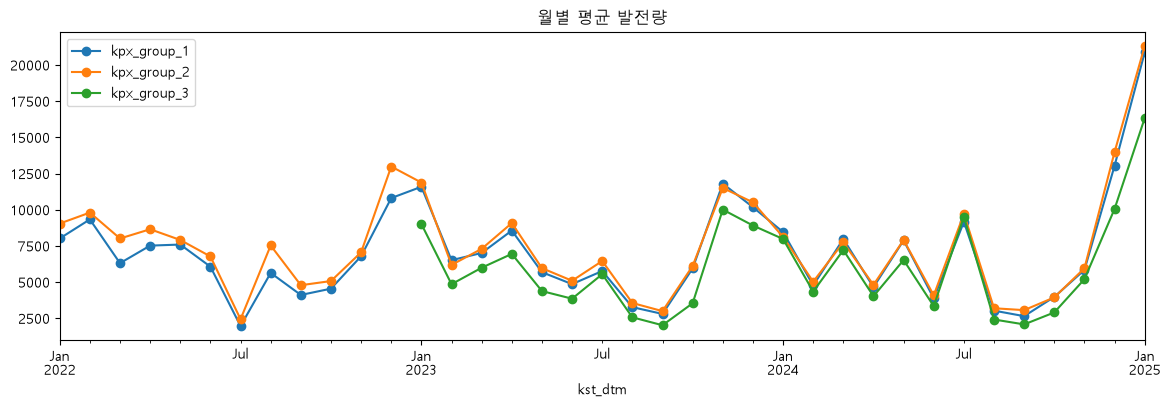

In [8]:
monthly = labels.set_index("kst_dtm")[GROUP_COLS].resample("MS").mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, marker="o")
ax.set_title("월별 평균 발전량")
plt.show()

In [9]:
# 24시간 이상 연속으로 0이 찍힌 구간이 몇 번 있는지 확인 (터빈 정지/결측 의심 구간 후보)
for col in GROUP_COLS:
    s = labels.set_index("kst_dtm")[col].dropna()
    is_zero = s == 0
    zero_run_id = (~is_zero).cumsum()
    run_lengths = is_zero.groupby(zero_run_id).sum()
    long_runs = run_lengths[run_lengths >= 24]
    print(col, "24시간 이상 연속 0 구간 개수:", len(long_runs))

kpx_group_1 24시간 이상 연속 0 구간 개수: 7
kpx_group_2 24시간 이상 연속 0 구간 개수: 6
kpx_group_3 24시간 이상 연속 0 구간 개수: 6


**확인할 것**
- 겨울(12~2월)이 여름보다 평균 발전량이 뚜렷이 높은지 (태백 산악풍 특성상 예상되는 패턴)
- 24시간 이상 연속 0 구간이 몇 번 있는지 — 있다면 다음 단계에서 그 날짜를 콕 집어 원인(정비/결측/실제 무풍)을 확인해야 합니다

### 1-6. 그룹 간 상관관계

세 그룹 모두 같은 가덕산 단지 안에 있으므로 날씨가 비슷해 상관이 높을 것으로 예상합니다. 상관이 실제로 얼마나 높은지 확인하면, 그룹을 따로 모델링할지 정보를 공유할지 판단하는 근거가 됩니다.

In [10]:
corr = labels[GROUP_COLS].corr()
corr

,kpx_group_1,kpx_group_2,kpx_group_3
kpx_group_1,1.000000,0.955350,0.903694
kpx_group_2,0.955350,1.000000,0.928294
kpx_group_3,0.903694,0.928294,1.000000


**확인할 것**
- 상관계수가 대부분 0.8 이상으로 높게 나오는지 (같은 단지이므로 예상되는 수준)
- 유독 상관이 낮은 쌍이 있다면 터빈 제작사(VESTAS vs UNISON) 차이나 위치 차이를 의심해볼 대상입니다

### 1-7. 시간대별(일주기) 평균 발전량

산악 지형은 낮과 밤의 기온차로 생기는 국지풍(산곡풍) 때문에 시간대별로 바람 패턴이 달라질 수 있습니다. 시간대별 평균을 보면 이 패턴이 실제로 존재하는지 확인할 수 있습니다.

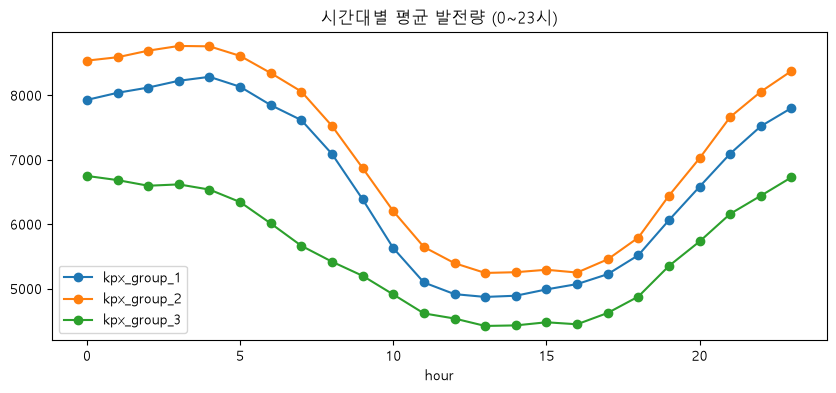

In [11]:
labels["hour"] = labels["kst_dtm"].dt.hour
hourly_profile = labels.groupby("hour")[GROUP_COLS].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_profile.plot(ax=ax, marker="o")
ax.set_title("시간대별 평균 발전량 (0~23시)")
plt.show()

**확인할 것**
- 특정 시간대(예: 새벽 vs 낮)에 뚜렷한 차이가 있는지
- 있다면 '시간(hour)'을 피처로 넣을 근거가 됩니다

### 1-8. 연도별 분포 변화 (Drift 확인)

CLAUDE.md 2.3절: 연도마다 기상 조건이 달라질 수 있어, 2022년 데이터를 많이 쓰는 것이 오히려 성능을 해칠 수도 있습니다. 연도별 분포를 비교해 이 위험이 실제로 있는지 확인합니다. 이 결과는 앞서 정한 A안+B안 병행 검증 전략의 근거를 강화하거나 재검토하는 데 씁니다.

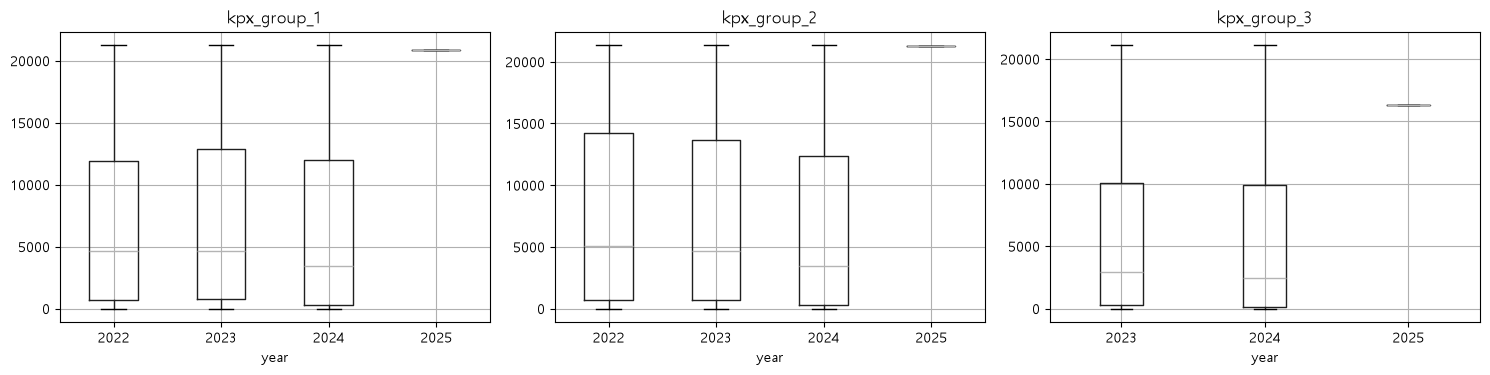

,kpx_group_1,kpx_group_2,kpx_group_3
year,,,
2022,6561.329096,7520.534942,NaN
2023,7000.421112,7226.109431,5638.874657
2024,6302.687647,6488.365732,5487.700727
2025,20870.337000,21304.232000,16328.905000


In [12]:
labels["year"] = labels["kst_dtm"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, GROUP_COLS):
    data = labels[["year", col]].dropna()
    data.boxplot(column=col, by="year", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

labels.groupby("year")[GROUP_COLS].mean()

**확인할 것**
- 연도별 중앙값·사분위 범위(박스 크기)가 눈에 띄게 다른 해가 있는지
- 있다면 검증 전략(A안: 2024를 검증으로 씀)에서 2024년이 대표성 있는 해인지 다시 짚어봐야 합니다

boxplot은 중앙값·사분위수 같은 요약 통계만 보여줘서, 분포 모양(예: 0 근처에 얼마나 몰려있는지, 봉우리가 몇 개인지) 자체를 놓칠 수 있습니다. 그래서 같은 데이터를 연도별 히스토그램을 겹쳐 그리는 방식으로 한 번 더 봅니다 — 두 그림은 서로 다른 걸 보여주므로 같이 봐야 합니다(boxplot=요약 통계 비교용, 히스토그램=분포 모양 비교용).

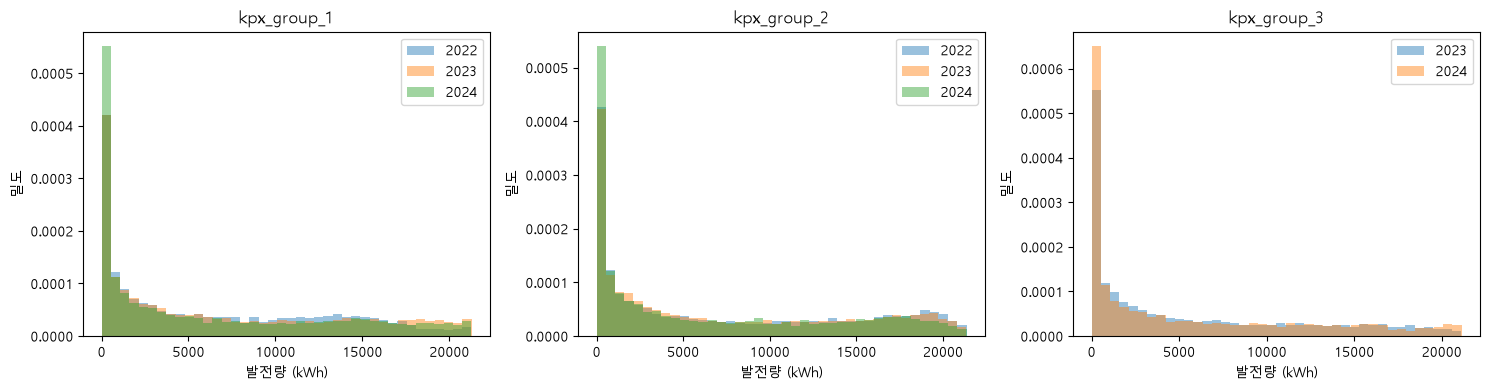

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, GROUP_COLS):
    for year in [2022, 2023, 2024]:  # 2025는 1행(2025-01-01 00:00)뿐이라 분포를 그릴 수 없어 제외
        data = labels.loc[labels["year"] == year, col].dropna()
        if len(data) == 0:
            continue
        ax.hist(data, bins=40, density=True, alpha=0.45, label=str(year))
    ax.set_xlabel("발전량 (kWh)")
    ax.set_ylabel("밀도")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

**확인할 것**: 연도별 히스토그램의 모양(0 근처로 쏠린 정도, 고발전 구간 비중)이 눈에 띄게 다른 해가 있는지 — 특정 연도만 0 근처 막대가 유난히 높거나 낮으면 그 해의 풍황이 달랐다는 뜻입니다. 위 boxplot에서 본 중앙값 차이가 분포 모양 차이와도 일치하는지 함께 봐주세요.

## 2. 기상 예보(GFS/LDAPS) 탐색

이제부터는 `01_preprocessing.ipynb`가 만든 parquet 캐시를 불러와서 봅니다. 이미 격자별로 넓게 펼쳐진 형태라, 매번 원본 CSV를 pivot할 필요가 없습니다.

In [14]:
train_base = pd.read_parquet(f"{PROCESSED_DIR}/train_base.parquet")
test_base = pd.read_parquet(f"{PROCESSED_DIR}/test_base.parquet")
gfs_grid_meta = pd.read_parquet(f"{PROCESSED_DIR}/gfs_grid_meta.parquet")
ldaps_grid_meta = pd.read_parquet(f"{PROCESSED_DIR}/ldaps_grid_meta.parquet")

print("train_base:", train_base.shape, "| test_base:", test_base.shape)
print("gfs_grid_meta:", gfs_grid_meta.shape, "| ldaps_grid_meta:", ldaps_grid_meta.shape)

train_base: (26304, 804) | test_base: (8760, 798)
gfs_grid_meta: (9, 3) | ldaps_grid_meta: (16, 3)


**확인할 것**: `train_base`가 `(26304, 804)`, `test_base`가 `(8760, 798)` — 01_preprocessing에서 확인한 값과 같아야 합니다.

### 2-1. 격자 위치 지도 — 터빈과 얼마나 가까운가

GFS는 9개, LDAPS는 16개 격자가 있습니다. 어느 격자가 실제 터빈(태백 가덕산)에 가장 가까운지 확인해야, 나중에(`03_features.ipynb`) '최근접 격자' 피처를 근거 있게 고를 수 있습니다.

`info.xlsx`의 '좌표(Google)'는 도-분-초(DMS, 예: `37°16'55.61"N`) 형식이라 십진수 좌표로 바꿔서 격자 위경도와 같은 그래프에 겹쳐 그립니다.

In [15]:
info = pd.read_excel("../data/info.xlsx", sheet_name="info", header=3)
info = info.dropna(subset=["호기"]).reset_index(drop=True)
info["KPX그룹"] = info["KPX그룹"].ffill()
info.head(3)

,Unnamed: 0,단계,명칭,제작사,모델명,호기,좌표(Google),KPX그룹,Hub Height(m),Rotor Diameter(m),설비용량(MW),그룹설비용량(MW)
0,NaN,1,태백가덕산,VESTAS,V126,1,"37°16'55.61""N 128°57'02.10""E",1.0,117,126,3.6,21.6
1,NaN,1,태백가덕산,VESTAS,V126,2,"37°17'04.05""N 128°56'58.35""E",1.0,117,126,3.6,NaN
2,NaN,1,태백가덕산,VESTAS,V126,3,"37°17'11.49""N 128°56'58.99""E",1.0,117,126,3.6,NaN


In [16]:
import re


def dms_to_decimal(dms_str: str) -> tuple[float, float]:
    """'37°16'55.61"N 128°57'02.10"E' 형태의 문자열을 (위도, 경도) 십진수로 변환."""
    pattern = r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NS])\s+(\d+)\D+(\d+)\D+([\d.]+)\D*([EW])"
    lat_d, lat_m, lat_s, lat_dir, lon_d, lon_m, lon_s, lon_dir = re.match(pattern, dms_str.strip()).groups()
    lat = float(lat_d) + float(lat_m) / 60 + float(lat_s) / 3600
    lon = float(lon_d) + float(lon_m) / 60 + float(lon_s) / 3600
    lat = -lat if lat_dir == "S" else lat
    lon = -lon if lon_dir == "W" else lon
    return lat, lon


turbine_coords = info[["제작사", "호기", "KPX그룹", "좌표(Google)"]].copy()
turbine_coords[["lat", "lon"]] = turbine_coords["좌표(Google)"].apply(lambda s: pd.Series(dms_to_decimal(s)))
turbine_coords.head(3)

,제작사,호기,KPX그룹,좌표(Google),lat,lon
0,VESTAS,1,1.0,"37°16'55.61""N 128°57'02.10""E",37.282114,128.950583
1,VESTAS,2,1.0,"37°17'04.05""N 128°56'58.35""E",37.284458,128.949542
2,VESTAS,3,1.0,"37°17'11.49""N 128°56'58.99""E",37.286525,128.949719


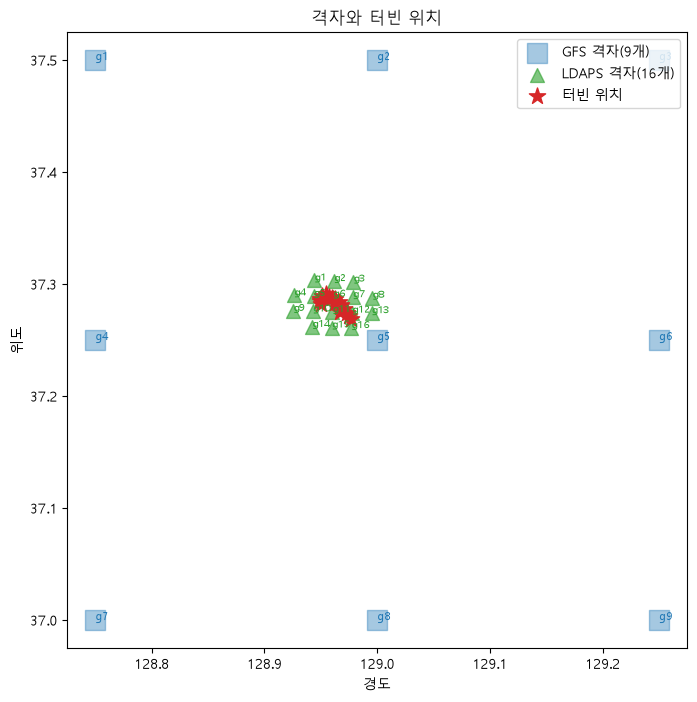

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(gfs_grid_meta["longitude"], gfs_grid_meta["latitude"], marker="s", s=200, c="tab:blue", alpha=0.4, label="GFS 격자(9개)")
ax.scatter(ldaps_grid_meta["longitude"], ldaps_grid_meta["latitude"], marker="^", s=100, c="tab:green", alpha=0.6, label="LDAPS 격자(16개)")
ax.scatter(turbine_coords["lon"], turbine_coords["lat"], marker="*", s=150, c="tab:red", label="터빈 위치")

for _, row in gfs_grid_meta.iterrows():
    ax.annotate(f"g{int(row['grid_id'])}", (row["longitude"], row["latitude"]), fontsize=8, color="tab:blue")
for _, row in ldaps_grid_meta.iterrows():
    ax.annotate(f"g{int(row['grid_id'])}", (row["longitude"], row["latitude"]), fontsize=7, color="tab:green")

ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("격자와 터빈 위치")
ax.legend()
plt.show()

**확인할 것**: 터빈(빨간 별)에 가장 가까운 GFS 격자 번호와 LDAPS 격자 번호가 몇 번인지 눈으로 확인해서 알려주세요 — `03_features.ipynb`에서 '최근접 격자' 피처를 만들 때 이 번호를 근거로 씁니다.

### 2-2. 결측치 컬럼별 분해

`reports/01_preprocessing.md`에 남겨둔 숙제입니다 — train_base 결측 17,741건, test_base 결측 752건이 정확히 어디서 나오는지 컬럼별로 쪼개봅니다.

In [18]:
train_na = train_base.isna().sum()
train_na = train_na[train_na > 0].sort_values(ascending=False)
print("train_base 결측 있는 컬럼 수:", len(train_na), "| 결측 총량:", train_na.sum())
train_na.head(20)

train_base 결측 있는 컬럼 수: 4 | 결측 총량: 17741


scada_kpx_group_3    8768
kpx_group_3          8766
kpx_group_1           104
kpx_group_2           103
dtype: int64

**확인할 것**: 상위권이 `kpx_group_3`, `scada_kpx_group_*` 처럼 원래 결측이 예상됐던 컬럼인지 확인하세요. 그 외 `gfs_*`/`ldaps_*` 예보 컬럼이 섞여 있다면 예보 누락일이 있다는 뜻이니, 몇 건인지·어떤 컬럼인지 알려주세요.

In [19]:
test_na = test_base.isna().sum()
test_na = test_na[test_na > 0].sort_values(ascending=False)
print("test_base 결측 있는 컬럼 수:", len(test_na), "| 결측 총량:", test_na.sum())
test_na.head(20)

test_base 결측 있는 컬럼 수: 304 | 결측 총량: 752


ldaps_g16_surface_0_lsm                   3
ldaps_g15_surface_0_lsm                   3
ldaps_g14_surface_0_lsm                   3
ldaps_g13_surface_0_lsm                   3
ldaps_g12_surface_0_lsm                   3
ldaps_g11_surface_0_lsm                   3
ldaps_g10_surface_0_lsm                   3
ldaps_g9_surface_0_lsm                    3
ldaps_g8_surface_0_lsm                    3
ldaps_g7_surface_0_lsm                    3
ldaps_g6_surface_0_lsm                    3
ldaps_g5_surface_0_lsm                    3
ldaps_g4_surface_0_lsm                    3
ldaps_g3_surface_0_lsm                    3
ldaps_g2_surface_0_lsm                    3
ldaps_g1_surface_0_lsm                    3
ldaps_g16_heightAboveGround_50_50MUmin    3
ldaps_g15_heightAboveGround_50_50MUmin    3
ldaps_g14_heightAboveGround_50_50MUmin    3
ldaps_g13_heightAboveGround_50_50MUmin    3
dtype: int64

In [20]:
# 결측이 있는 컬럼 중 하나를 골라, 실제로 어떤 시각에 결측인지 확인 (예보 누락일 후보 특정)
if len(test_na) > 0:
    sample_col = test_na.index[0]
    missing_times = test_base.loc[test_base[sample_col].isna(), "kst_dtm"]
    print(sample_col, "결측 시각 (", len(missing_times), "건):")
    print(missing_times)
else:
    print("test_base에 결측 없음")

ldaps_g16_surface_0_lsm 결측 시각 ( 3 건):
2344   2025-04-08 17:00:00
4049   2025-06-18 18:00:00
4757   2025-07-18 06:00:00
Name: kst_dtm, dtype: datetime64[us]


**확인할 것**: 결측 시각이 특정 날짜(예보 누락일)에 몰려 있는지, 아니면 여기저기 흩어져 있는지. 몰려 있다면 그 날짜를 기록해뒀다가 `03_features.ipynb`에서 보간(앞뒤 값으로 채우기 등) 방침을 정합니다.

### 2-3. 풍속 계산과 높이별·소스별 비교

바람은 u(동서 방향 성분), v(남북 방향 성분)로 나뉘어 있습니다. 파워커브와 비교하려면 방향과 상관없는 '풍속(속력)'이 필요한데, 피타고라스 정리와 같은 방식으로 **풍속 = sqrt(u² + v²)** 로 구합니다.

In [21]:
def wind_speed(df, u_col, v_col):
    return np.sqrt(df[u_col] ** 2 + df[v_col] ** 2)


# GFS: 9개 격자 평균 풍속을 높이별(10m/80m/100m/850hPa)로 계산
gfs_height_cols = {
    "10m": ("heightAboveGround_10_10u", "heightAboveGround_10_10v"),
    "80m": ("heightAboveGround_80_u", "heightAboveGround_80_v"),
    "100m": ("heightAboveGround_100_100u", "heightAboveGround_100_100v"),
    "850hPa": ("isobaricInhPa_850_u", "isobaricInhPa_850_v"),
}
for height, (u_suffix, v_suffix) in gfs_height_cols.items():
    speeds = [wind_speed(train_base, f"gfs_g{g}_{u_suffix}", f"gfs_g{g}_{v_suffix}") for g in range(1, 10)]
    train_base[f"gfs_ws_{height}_mean"] = pd.concat(speeds, axis=1).mean(axis=1)

# LDAPS: 16개 격자 평균 풍속 (10m만 u/v로 깔끔하게 존재)
ldaps_speeds = [wind_speed(train_base, f"ldaps_g{g}_heightAboveGround_10_10u", f"ldaps_g{g}_heightAboveGround_10_10v") for g in range(1, 17)]
train_base["ldaps_ws_10m_mean"] = pd.concat(ldaps_speeds, axis=1).mean(axis=1)

WS_COLS = ["gfs_ws_10m_mean", "gfs_ws_80m_mean", "gfs_ws_100m_mean", "gfs_ws_850hPa_mean", "ldaps_ws_10m_mean"]
train_base[WS_COLS].describe()

,gfs_ws_10m_mean,gfs_ws_80m_mean,gfs_ws_100m_mean,gfs_ws_850hPa_mean,ldaps_ws_10m_mean
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2.607444,3.684370,3.833557,8.037832,4.836247
std,1.364537,2.380676,2.534866,5.782873,2.479576
min,0.314381,0.326878,0.302544,0.368424,0.371642
25%,1.722248,2.103818,2.143360,3.400416,2.965037
50%,2.304835,3.067921,3.159977,6.321069,4.321871
75%,3.041773,4.434781,4.649444,11.625509,6.278099
max,13.128982,19.936785,21.017444,35.855114,16.874288


**확인할 것**: 평균 풍속이 10m < 80m < 100m 순으로 커지는지 — 이걸 **윈드시어**(높이가 올라갈수록 지표 마찰의 영향이 줄어 바람이 빨라지는 현상, 멱법칙으로 근사됨)라고 부르고, 실제로 이렇게 나와야 물리적으로 타당합니다. 850hPa(약 1,500m 상공)은 지상보다 훨씬 클 수 있습니다.

**참고**: LDAPS는 시간 평균 u/v가 깔끔하게 있는 높이가 10m뿐입니다. `heightAboveGround_50_50MUmax/min`, `50MVmax/min`(50m 바람의 시간 내 최댓값/최솟값)과 `heightAboveGround_5_XBLWS/YBLWS`(5m 경계층 바람)도 있지만 평균값이 아니라서 지금은 쓰지 않았습니다. 50m max/min은 `(max+min)/2`로 근사 평균을, `max-min`으로 돌풍성(그 시간 안의 풍속 변동폭) 피처를 만들 수 있어 `03_features.ipynb` 단계 숙제로 남겨둡니다.

In [22]:
for group_col in GROUP_COLS:
    print(f"--- {group_col} ---")
    for col in WS_COLS:
        corr = train_base[col].corr(train_base[group_col])
        print(" ", col, "- 상관:", round(corr, 4))
    print()

--- kpx_group_1 ---
  gfs_ws_10m_mean - 상관: 0.5395
  gfs_ws_80m_mean - 상관: 0.5686
  gfs_ws_100m_mean - 상관: 0.5736
  gfs_ws_850hPa_mean - 상관: 0.7389
  ldaps_ws_10m_mean - 상관: 0.7298

--- kpx_group_2 ---
  gfs_ws_10m_mean - 상관: 0.5488
  gfs_ws_80m_mean - 상관: 0.5809
  gfs_ws_100m_mean - 상관: 0.5866
  gfs_ws_850hPa_mean - 상관: 0.7689
  ldaps_ws_10m_mean - 상관: 0.7395

--- kpx_group_3 ---
  gfs_ws_10m_mean - 상관: 0.5448
  gfs_ws_80m_mean - 상관: 0.5778
  gfs_ws_100m_mean - 상관: 0.5832
  gfs_ws_850hPa_mean - 상관: 0.7416
  ldaps_ws_10m_mean - 상관: 0.7338



**확인할 것**: 어느 높이의 풍속이 발전량과 가장 상관이 높은지 순위를 매겨서 알려주세요 — `03_features.ipynb`에서 어떤 높이를 주력 피처로 쓸지 정하는 근거가 됩니다.

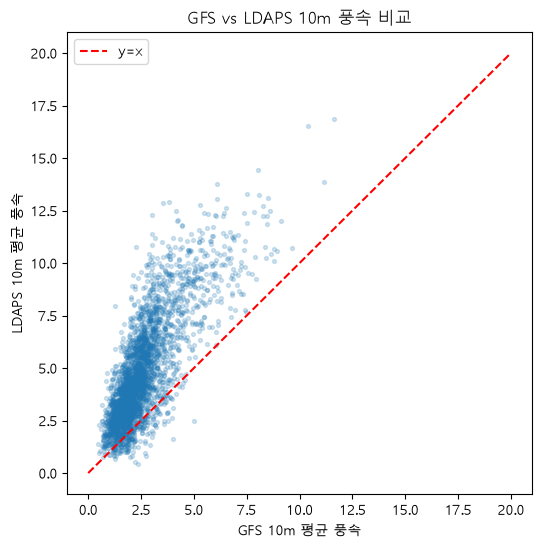

GFS-LDAPS 10m 풍속 상관: 0.7825


In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
sample = train_base.sample(3000, random_state=SEED)
ax.scatter(sample["gfs_ws_10m_mean"], sample["ldaps_ws_10m_mean"], alpha=0.2, s=8)
ax.plot([0, 20], [0, 20], color="red", linestyle="--", label="y=x")
ax.set_xlabel("GFS 10m 평균 풍속")
ax.set_ylabel("LDAPS 10m 평균 풍속")
ax.set_title("GFS vs LDAPS 10m 풍속 비교")
ax.legend()
plt.show()

print("GFS-LDAPS 10m 풍속 상관:", round(train_base["gfs_ws_10m_mean"].corr(train_base["ldaps_ws_10m_mean"]), 4))

**확인할 것**: 점들이 빨간 y=x 선 근처에 모여 있는지(두 예보가 비슷하게 맞다는 뜻), 아니면 한쪽이 체계적으로 높거나 낮은지(편향). 차이가 크면 '두 소스가 서로 다르게 말한다'는 것 자체가 불확실성 정보이므로, 나중에 두 예측값의 차이를 피처로 쓸 근거가 됩니다.

### 2-4. 물리적 범위 점검

단위가 잘못 섞여 있으면(예: 켈빈과 섭씨 혼용) 항상 물리적으로 말이 안 되는 범위가 나옵니다. 대표 컬럼 몇 개만 범위를 확인합니다.

In [24]:
print("GFS g1 2m 기온(예상: 켈빈, K) 범위:", train_base["gfs_g1_heightAboveGround_2_2t"].min(), "~", train_base["gfs_g1_heightAboveGround_2_2t"].max())
print("LDAPS g1 2m 기온(예상: 켈빈, K) 범위:", train_base["ldaps_g1_heightAboveGround_2_t"].min(), "~", train_base["ldaps_g1_heightAboveGround_2_t"].max())
print("GFS g1 지표기압(예상: Pa) 범위:", train_base["gfs_g1_surface_0_sp"].min(), "~", train_base["gfs_g1_surface_0_sp"].max())

GFS g1 2m 기온(예상: 켈빈, K) 범위: 251.20033 ~ 305.82446
LDAPS g1 2m 기온(예상: 켈빈, K) 범위: 249.74907 ~ 302.03574
GFS g1 지표기압(예상: Pa) 범위: 90688.234 ~ 94558.96


**확인할 것**: 기온이 대략 230~320(켈빈, 섭씨 -43~47도에 해당 — 태백 지역 극한 기온을 넉넉히 포함하는 범위) 사이인지, 기압이 대략 85,000~103,000(Pa) 사이인지. 크게 벗어나면 단위 문제를 의심해야 합니다.

## 3. 타깃 × 기상 관계 심화 (파워커브 · 풍향별 발전량 · 계절×풍속 상호작용)

2절에서는 "어떤 높이·어떤 소스의 풍속이 발전량과 상관이 높은가"를 숫자(상관계수)로만 봤습니다. 이번 절에서는 그 관계의 **모양**을 직접 눈으로 확인합니다.

- 3-1: 풍속과 발전량의 관계가 정말 파워커브(power curve, 풍속-발전량 관계를 나타내는 S자형 곡선 — 자동차 계기판의 RPM-속도 곡선처럼 터빈마다 정해진 고유한 곡선) 모양인지
- 3-2: 풍향(바람이 불어오는 방향)에 따라 발전량이 달라지는지 — 산 능선을 넘어오는 바람과 능선을 따라 부는 바람은 터빈이 실제로 맞는 바람 세기가 다를 수 있습니다
- 3-3: 같은 풍속이라도 겨울과 여름에 발전량이 다른지 — 공기밀도(같은 부피 안에 들어있는 공기 분자의 양. 겨울엔 공기가 "빽빽해서" 무겁고, 여름엔 "성겨서" 가볍습니다) 때문에 발전량은 풍속의 세제곱뿐 아니라 공기밀도에도 비례합니다(발전량 ∝ 공기밀도 × 풍속³)

이번 절부터는 그룹마다 **가장 가까운 LDAPS 격자**(2절에서 터빈-격자 거리로 확인: group_1→g5, group_2→g6, group_3→g12)의 바람만 씁니다 — 16개 격자를 평균 내는 것보다, 실제 그 그룹의 터빈이 맞는 바람에 더 가깝기 때문입니다.

### 3-1. 파워커브 확인 — 풍속 vs 발전량 산점도

**무엇을/왜**: 각 그룹의 최근접 LDAPS 격자 10m 풍속과 발전량을 산점도로 그립니다. 터빈의 파워커브(전력곡선)는 이론적으로 3단계입니다.
1. 컷인(cut-in, 터빈이 돌기 시작하는 최소 풍속) 이하 — 발전량 0 근처에서 평평
2. 컷인 ~ 정격(rated) 풍속 — 풍속이 오를수록 발전량이 급격히 증가 (이론상 대략 풍속³에 비례)
3. 정격 풍속 이상 — 설비용량 근처에서 다시 평평 (더 세게 불어도 안전을 위해 더 이상 뽑지 않음)

이 3단계 모양이 실제로 보이는지 확인하면, 컷인·정격 풍속을 데이터에서 직접 읽어낼 수 있습니다(공식 터빈 스펙 문서가 따로 없으므로, 그래프에서 관찰한 값을 근거로 삼습니다 — CLAUDE.md 2.7절, 추측이 아니라 데이터 근거로 판단).

In [25]:
GROUP_NEAREST_LDAPS = {
    "kpx_group_1": 5,
    "kpx_group_2": 6,
    "kpx_group_3": 12,
}  # 2절 격자-터빈 거리 계산으로 확인한 그룹별 최근접 LDAPS 격자

for group_col, grid_id in GROUP_NEAREST_LDAPS.items():
    train_base[f"{group_col}_ws_nearest"] = wind_speed(
        train_base, f"ldaps_g{grid_id}_heightAboveGround_10_10u", f"ldaps_g{grid_id}_heightAboveGround_10_10v"
    )

train_base[[f"{g}_ws_nearest" for g in GROUP_COLS]].describe()

,kpx_group_1_ws_nearest,kpx_group_2_ws_nearest,kpx_group_3_ws_nearest
count,26304.000000,26304.000000,26304.000000
mean,4.779440,5.091271,5.196616
std,2.434159,2.526631,2.765333
min,0.037558,0.038639,0.072987
25%,3.056498,3.180371,2.989968
50%,4.259118,4.646858,4.691264
75%,6.017516,6.619826,7.039176
max,17.220675,17.583720,17.304098


**확인할 것**: 세 그룹의 평균 풍속이 서로 비슷한 범위인지(격자가 가까우니 크게 다르면 안 됨), 2절에서 본 전체 격자 평균(LDAPS 10m 평균 4.84 m/s)과 비슷한 수준인지 확인해 주세요.

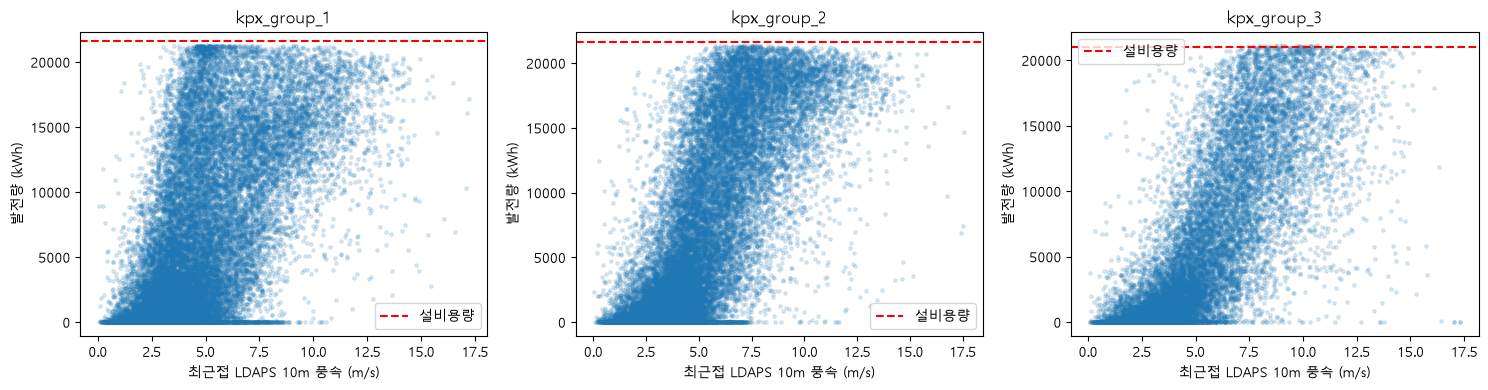

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    ws_col = f"{group_col}_ws_nearest"
    sample = train_base[[ws_col, group_col]].dropna()
    ax.scatter(sample[ws_col], sample[group_col], alpha=0.15, s=6)
    ax.axhline(CAPACITY_KWH[group_col], color="red", linestyle="--", label="설비용량")
    ax.set_xlabel("최근접 LDAPS 10m 풍속 (m/s)")
    ax.set_ylabel("발전량 (kWh)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

**확인할 것**: 산점도가 이론적인 3단계(저풍속=0 근처 평평 → 중간 급증 → 고풍속=설비용량 근처 평평) 모양으로 보이는지, 급증이 시작되는 지점(컷인 풍속)과 평평해지기 시작하는 지점(정격 풍속)을 눈대중으로 몇 m/s쯤인지 알려주세요. 그룹마다 곡선 모양이나 꺾이는 지점이 다르면(터빈 제작사가 group_1/2는 VESTAS, group_3은 UNISON으로 다름) 그것도 알려주세요.

### 3-2. 풍향별 평균 발전량 — 바람장미(wind rose)

**무엇을/왜**: u(동서 성분)·v(남북 성분)로부터 풍향(바람이 불어오는 방향, 나침반 각도로 0°=북·90°=동·180°=남·270°=서)을 계산하고, 16방위(N, NNE, NE, ... )로 나눠 방위별 평균 발전량을 봅니다. 태백 가덕산은 산 능선 지형이라, 능선을 정면으로 넘어오는 바람과 능선을 따라(측면으로) 부는 바람은 터빈이 실제로 맞는 유효 바람이 다를 수 있습니다(지형에 의한 가속·차폐 효과) — 이걸 확인하면 "풍향" 또는 "풍향-능선 각도" 같은 피처를 만들 근거가 생깁니다.

풍향은 기상학 표준 공식으로 계산합니다: `풍향(도) = (270 - atan2(v, u)를 도로 변환) mod 360`. (예: 정북에서 남쪽으로 곧장 부는 바람은 풍향 0°/360°, 즉 "북풍"이라고 부릅니다 — 방위 이름은 바람이 "불어오는" 쪽 기준입니다.)

In [27]:
def wind_direction_deg(u, v):
    """기상학적 풍향(바람이 '불어오는' 방향, 0=북 90=동 180=남 270=서, 도 단위)을 계산."""
    return (270 - np.degrees(np.arctan2(v, u))) % 360


DIRECTIONS_16 = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
                 "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]


def to_16_sector(deg):
    idx = int(np.round(deg / 22.5)) % 16
    return DIRECTIONS_16[idx]


for group_col, grid_id in GROUP_NEAREST_LDAPS.items():
    u_col = f"ldaps_g{grid_id}_heightAboveGround_10_10u"
    v_col = f"ldaps_g{grid_id}_heightAboveGround_10_10v"
    deg = wind_direction_deg(train_base[u_col], train_base[v_col])
    train_base[f"{group_col}_wd_sector"] = deg.apply(to_16_sector)

train_base[[f"{g}_wd_sector" for g in GROUP_COLS]].apply(lambda s: s.value_counts()).reindex(DIRECTIONS_16).fillna(0).astype(int)

,kpx_group_1_wd_sector,kpx_group_2_wd_sector,kpx_group_3_wd_sector
N,215,311,306
NNE,440,396,649
NE,1105,1179,1655
ENE,2401,2312,2116
E,1484,1345,875
ESE,866,717,526
SE,740,767,800
SSE,536,655,769
S,352,488,579
SSW,476,419,480


**확인할 것**: 어느 방위에 시간이 가장 많이 몰려있는지(이 지역의 주풍향), 그룹 간 주풍향이 비슷한지(격자가 가까우니 비슷해야 정상) 확인해 주세요.

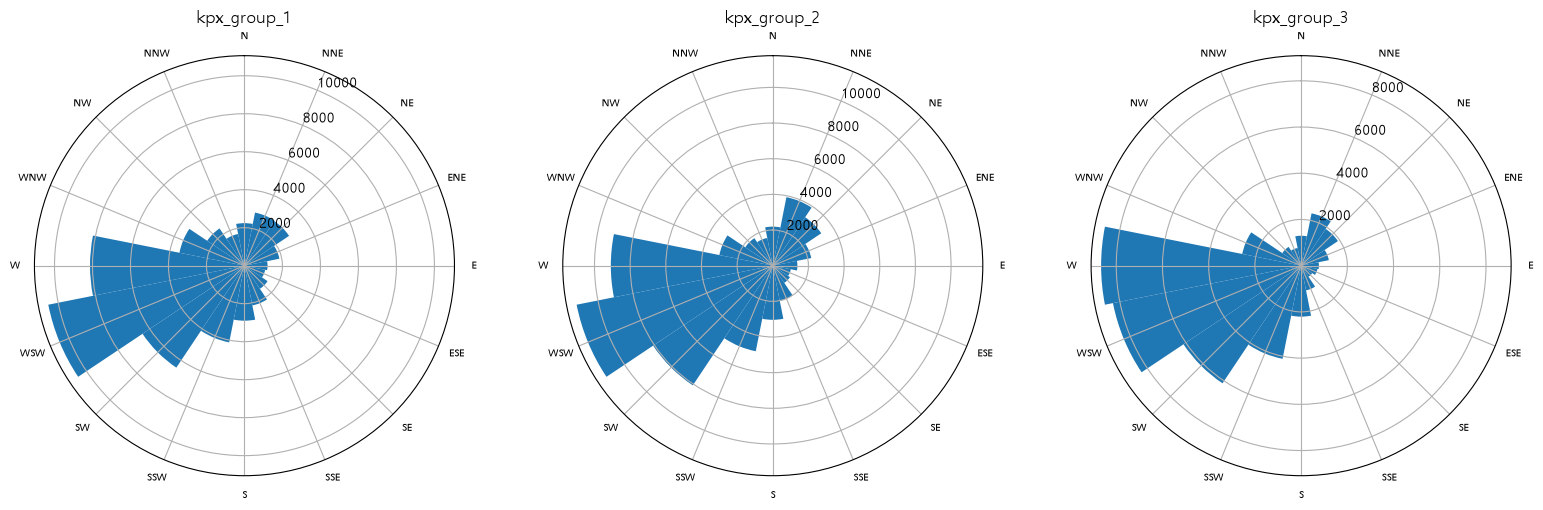

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={"projection": "polar"})
angles = np.deg2rad(np.arange(0, 360, 22.5))
for ax, group_col in zip(axes, GROUP_COLS):
    profile = train_base.groupby(f"{group_col}_wd_sector")[group_col].mean().reindex(DIRECTIONS_16)
    ax.bar(angles, profile.values, width=2 * np.pi / 16, align="center")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(DIRECTIONS_16, fontsize=7)
    ax.set_title(group_col)
plt.tight_layout()
plt.show()

**확인할 것**: 특정 방위(예: 서풍·북서풍 계열)에서 막대가 뚜렷이 긴(=평균 발전량이 높은) 방위가 있는지, 그 방위가 바로 앞 셀에서 확인한 "가장 자주 부는 방향(주풍향)"과 같은지 다른지 알려주세요. 같으면 "자주 불고 발전도 잘 되는 방향"이고, 다르면 "드물게 불지만 그 방향일 때만 세게 불어 발전량이 튀는 방향"일 수 있습니다 — 둘은 피처 설계에서 의미가 다릅니다.

### 3-3. 계절(겨울 vs 여름) × 풍속 상호작용 — 공기밀도 효과 확인

**무엇을/왜**: 터빈이 뽑아내는 전력은 이론적으로 `발전량 ∝ 공기밀도 × 풍속³`입니다. 공기밀도는 기온이 낮을수록 커지므로(같은 부피 안에 공기 분자가 더 빽빽하게 들어참), **같은 풍속이라도 겨울이 여름보다 발전량이 높아야** 물리적으로 맞습니다. 이걸 실제로 확인하면 `03_features.ipynb`에서 "기온(또는 공기밀도)"을 별도 피처로 넣을 근거가 됩니다 — 안 넣으면 모델이 겨울/여름 차이를 풍속만으로 설명하려다 오차가 생길 수 있습니다.

풍속을 1m/s 단위 구간으로 나누고, 구간마다 겨울(12·1·2월)과 여름(6·7·8월)의 평균 발전량을 비교합니다.

In [29]:
train_base["month"] = train_base["kst_dtm"].dt.month
season_map = {12: "겨울", 1: "겨울", 2: "겨울", 6: "여름", 7: "여름", 8: "여름"}
train_base["season"] = train_base["month"].map(season_map)

WS_BIN_EDGES = np.arange(0, 16, 1)
for group_col in GROUP_COLS:
    train_base[f"{group_col}_ws_bin"] = pd.cut(train_base[f"{group_col}_ws_nearest"], WS_BIN_EDGES)

train_base["season"].value_counts(dropna=False)

season
NaN    13176
여름      6624
겨울      6504
Name: count, dtype: int64

**확인할 것**: 겨울·여름 각각 몇 시간씩 있는지(비교가 의미 있으려면 둘 다 최소 수천 시간은 있어야 합니다), `season`이 NaN인 시간(3~5월·9~11월 봄가을)이 제외되는 게 맞는지 확인해 주세요.

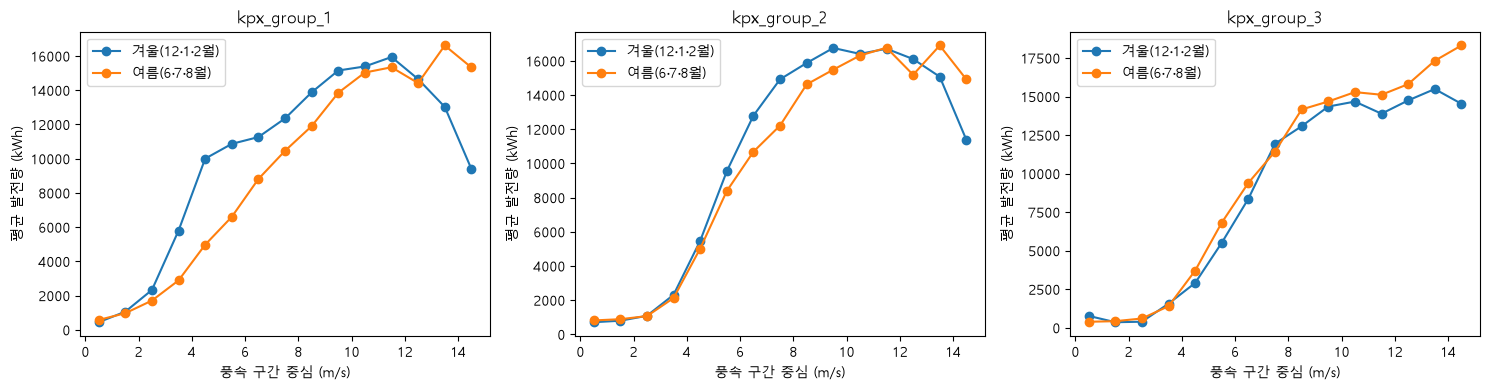

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    sub = train_base.dropna(subset=["season", group_col, f"{group_col}_ws_bin"])
    profile = sub.groupby(["season", f"{group_col}_ws_bin"], observed=True)[group_col].mean().unstack("season")
    bin_centers = [interval.mid for interval in profile.index]
    ax.plot(bin_centers, profile["겨울"], marker="o", label="겨울(12·1·2월)")
    ax.plot(bin_centers, profile["여름"], marker="o", label="여름(6·7·8월)")
    ax.set_xlabel("풍속 구간 중심 (m/s)")
    ax.set_ylabel("평균 발전량 (kWh)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

**확인할 것**: 같은 풍속 구간에서 겨울(주황/파랑 중 겨울 선) 값이 여름 선보다 위에 있는지 — 공기밀도 가설(겨울 공기가 더 무거워 같은 바람에도 발전량이 더 많음)과 일치하는지 봐주세요. 만약 차이가 거의 없거나 반대로 나온다면, 이 사이트에서는 공기밀도 효과보다 다른 요인(예: 겨울철 결빙에 의한 터빈 성능 저하)이 더 클 수 있다는 뜻이니 그대로 알려주세요.

## 4. SCADA 심화 분석 (실측 데이터로 앞선 가설들 검증)

지금까지는 전부 **예보(GFS/LDAPS)** 데이터로 추론했습니다. 예보는 미래를 맞히기 위한 값이라 어쩔 수 없이 오차가 있습니다. 하지만 SCADA(터빈에 실제로 달린 센서가 10분마다 기록한 값 — 자동차의 실제 주행 기록계 같은 것)는 **그 시각에 진짜 무슨 일이 있었는지**를 보여줍니다. 이 절에서는 SCADA 실측 풍속을 이용해 1~3절에서 남겨둔 가설들을 검증합니다.

**주의**: SCADA는 test(2025년) 기간엔 없습니다(CLAUDE.md 절대규칙 — 평가 기간 실제 발전량·SCADA 사용 금지). 그래서 SCADA는 **모델에 넣을 피처가 아니라, "우리가 지금까지 쓴 예보 기반 피처가 얼마나 실제와 가까운가"를 검증하는 분석 도구**로만 씁니다.

이번 절에서 확인할 것:
- 4-1: SCADA 실측 풍속을 그룹별·시간별로 집계
- 4-2: SCADA 실측 풍속 vs LDAPS 예보 풍속 — 예보가 실제와 얼마나 다른지(예보 오차의 하한)
- 4-3: SCADA 풍속 기준 "진짜" 파워커브 + 이상 패턴(음수 발전량, 바람은 충분한데 발전량 0인 경우)
- 4-4: 일주기 저점(13~16시)이 curtailment 때문인지 실제 풍속 저하 때문인지
- 4-5: 1절에서 찾은 "24시간 이상 연속 0" 구간이 curtailment/정지인지 진짜 무풍인지
- 4-6: 3-3에서 본 계절×풍속 상호작용이 SCADA 실측 풍속으로도 재현되는지

### 4-1. SCADA 실측 풍속 불러오기 — 그룹별·시간별로 집계

**무엇을**: `scada_vestas_train.csv`(그룹1·2, 터빈 12기), `scada_unison_train.csv`(그룹3, 터빈 5기)에는 터빈마다 10분 단위 풍속(`_ws`) 컬럼이 있습니다. `01_preprocessing.ipynb`에서 발전량(`_power_kw10m`)은 이미 그룹별 1시간 합계로 만들어 `train_base`에 있지만, **풍속은 아직 한 번도 집계하지 않았습니다** — 이번 절에서 처음 씁니다.

**왜**: SCADA 풍속은 터빈에 직접 달린 풍속계가 잰 값이라, 지금까지 쓴 LDAPS 10m 예보보다 실제 터빈이 맞는 바람(허브고도 117m 부근)에 훨씬 가깝습니다.

**어떻게**: 발전량과 달리 풍속은 "더하면" 안 되고 "평균"을 내야 합니다(6개의 10분 풍속을 더하면 말이 안 되죠 — 시속을 6번 더하지 않는 것과 같습니다). 그래서 10분→1시간은 평균, 터빈→그룹도 평균으로 집계합니다. 시간 경계(`closed="right", label="right"`)는 발전량 집계 때와 똑같이 맞춥니다(`01_preprocessing.ipynb`에서 확정한 규칙).

In [31]:
scada_vestas_raw = pd.read_csv("../data/train/scada_vestas_train.csv", encoding="utf-8-sig", parse_dates=["kst_dtm"])
scada_unison_raw = pd.read_csv("../data/train/scada_unison_train.csv", encoding="utf-8-sig", parse_dates=["kst_dtm"])

# 01_preprocessing.ipynb에서 확정한 터빈-그룹 매핑과 동일 (VESTAS 1~6→그룹1, 7~12→그룹2, UNISON 1~5→그룹3)
TURBINE_GROUP_MAP = {}
for i in range(1, 7):
    TURBINE_GROUP_MAP[f"vestas_wtg{i:02d}"] = "kpx_group_1"
for i in range(7, 13):
    TURBINE_GROUP_MAP[f"vestas_wtg{i:02d}"] = "kpx_group_2"
for i in range(1, 6):
    TURBINE_GROUP_MAP[f"unison_wtg{i:02d}"] = "kpx_group_3"


def hourly_group_ws(df, group_map):
    """10분 단위 터빈별 풍속 -> 1시간 단위 KPX 그룹별 평균 풍속."""
    ws_cols = [c for c in df.columns if c.endswith("_ws")]
    hourly = df.set_index("kst_dtm")[ws_cols].resample("h", closed="right", label="right").mean()
    group_result = {}
    for col in ws_cols:
        turbine = col.replace("_ws", "")
        group = group_map[turbine]
        group_result.setdefault(group, []).append(col)
    return pd.DataFrame({group: hourly[cols].mean(axis=1) for group, cols in group_result.items()})


scada_ws_hourly = pd.concat(
    [hourly_group_ws(scada_vestas_raw, TURBINE_GROUP_MAP), hourly_group_ws(scada_unison_raw, TURBINE_GROUP_MAP)],
    axis=1,
)
scada_ws_hourly = scada_ws_hourly.add_prefix("scada_ws_").reset_index()

train_base = train_base.merge(scada_ws_hourly, on="kst_dtm", how="left")
train_base[[f"scada_ws_{g}" for g in GROUP_COLS]].describe()

,scada_ws_kpx_group_1,scada_ws_kpx_group_2,scada_ws_kpx_group_3
count,26304.000000,26304.000000,17536.000000
mean,6.782880,7.203019,5.848059
std,3.365441,3.855660,3.605820
min,0.000000,0.000000,0.570333
25%,4.147361,4.170236,2.828167
50%,6.326667,6.440292,5.015000
75%,9.080556,9.786111,8.075417
max,22.431528,25.201333,23.766000


**확인할 것**: SCADA 평균 풍속이 2절에서 본 LDAPS 10m 평균(4.84 m/s)보다 뚜렷이 높은지 — 높다면 윈드시어(허브고도가 10m보다 바람이 셈) 방향과 일치하는 정상적인 결과입니다. 그룹3(UNISON)만 결측이 있을 수 있는데(2022년엔 UNISON 자체가 없음), 결측 건수가 대략 8,760건대(2022년 1년치)인지 확인해 주세요.

### 4-2. SCADA 실측 풍속 vs LDAPS 예보 풍속 — "예보가 얼마나 틀리는가"

**무엇을/왜**: 지금까지 3절까지 쓴 "최근접 LDAPS 10m 풍속"은 어차피 예보라서 실제와 다를 수밖에 없습니다. SCADA(진짜 값)와 얼마나 차이 나는지 확인하면, **모델이 아무리 잘해도 넘을 수 없는 오차의 하한선**을 가늠할 수 있습니다(예보 자체가 실제와 몇 m/s씩 다르다면, 그 예보로 만든 어떤 피처도 그 이상 정확할 수 없습니다).

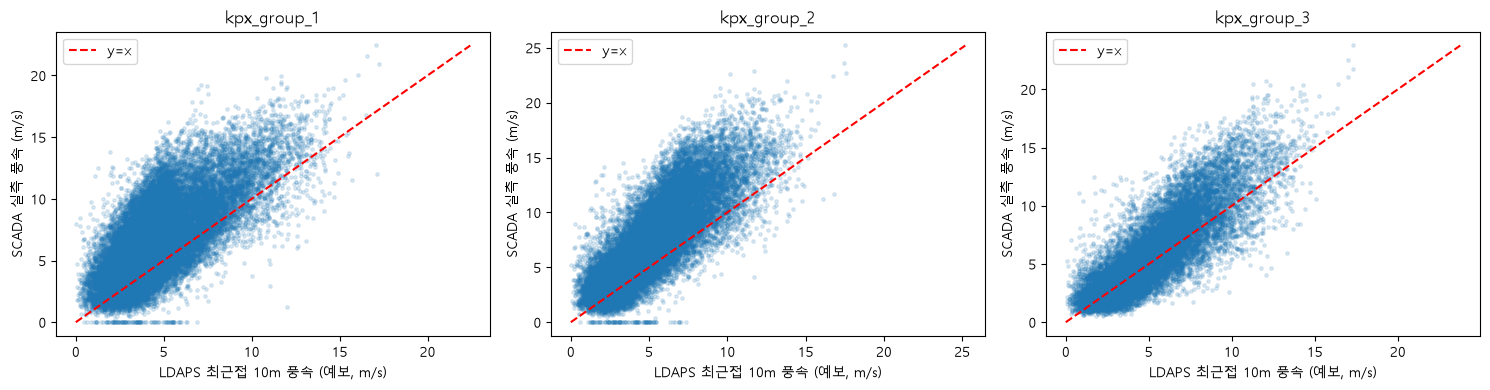

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    scada_col = f"scada_ws_{group_col}"
    proxy_col = f"{group_col}_ws_nearest"
    sample = train_base[[proxy_col, scada_col]].dropna()
    ax.scatter(sample[proxy_col], sample[scada_col], alpha=0.15, s=6)
    lims = [0, max(sample[proxy_col].max(), sample[scada_col].max())]
    ax.plot(lims, lims, color="red", linestyle="--", label="y=x")
    ax.set_xlabel("LDAPS 최근접 10m 풍속 (예보, m/s)")
    ax.set_ylabel("SCADA 실측 풍속 (m/s)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

In [33]:
for group_col in GROUP_COLS:
    scada_col = f"scada_ws_{group_col}"
    proxy_col = f"{group_col}_ws_nearest"
    sub = train_base[[scada_col, proxy_col]].dropna()
    bias = (sub[scada_col] - sub[proxy_col]).mean()
    rmse = ((sub[scada_col] - sub[proxy_col]) ** 2).mean() ** 0.5
    corr = sub[scada_col].corr(sub[proxy_col])
    corr_power = train_base[scada_col].corr(train_base[group_col])
    print(f"{group_col}: 예보-실측 상관={corr:.4f}  편향(실측-예보)={bias:+.2f}m/s  RMSE={rmse:.2f}m/s  |  SCADA풍속-발전량 상관={corr_power:.4f}")

kpx_group_1: 예보-실측 상관=0.7121  편향(실측-예보)=+2.00m/s  RMSE=3.10m/s  |  SCADA풍속-발전량 상관=0.9273
kpx_group_2: 예보-실측 상관=0.8114  편향(실측-예보)=+2.11m/s  RMSE=3.15m/s  |  SCADA풍속-발전량 상관=0.9395
kpx_group_3: 예보-실측 상관=0.8425  편향(실측-예보)=+0.73m/s  RMSE=2.09m/s  |  SCADA풍속-발전량 상관=0.9112


**확인할 것**: 점들이 y=x선보다 위쪽에 쏠려 있는지(=예보가 실제보다 낮게 예측하는 편향, 윈드시어 때문에 당연히 예상되는 방향), 편향이 몇 m/s쯤 되는지, RMSE가 얼마나 큰지 알려주세요. 마지막 줄의 "SCADA풍속-발전량 상관"이 2·3절에서 본 예보 기반 최고 상관(GFS 850hPa ≈ 0.74~0.77)보다 훨씬 높다면(예: 0.9 이상), "10m/100m 예보가 허브고도 풍속의 불완전한 대리변수"라는 1~3절의 가설이 확정되는 것입니다.

### 4-3. SCADA 풍속 기준 "진짜" 파워커브 + 이상 패턴 확인

**무엇을**: 이번엔 예보가 아니라 SCADA 실측 풍속으로 파워커브를 다시 그립니다. 3-1의 파워커브(예보 기반)와 비교해서 얼마나 더 촘촘한 S자 곡선이 되는지 봅니다. 그리고 라벨 신뢰도를 점검하는 차원에서 (1) 음수 발전량이 있는지, (2) 바람은 충분히 부는데(3 m/s 초과, 3-1에서 관찰한 대략적인 컷인 근방) 발전량이 0인 시간이 얼마나 되는지도 셉니다 — 있다면 curtailment/정지 후보입니다(CLAUDE.md 2.4절, 삭제하지 않고 패턴으로 이해).

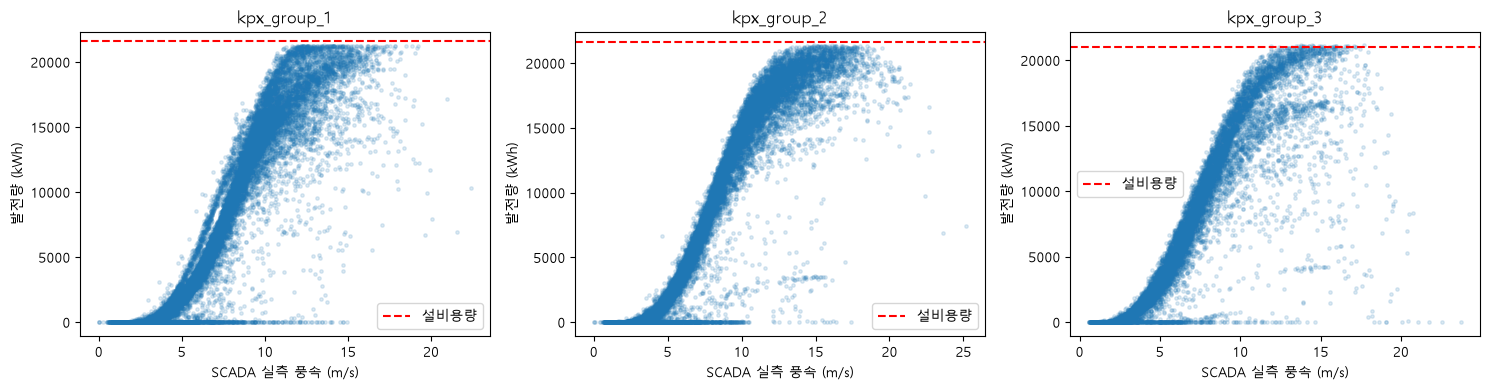

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    scada_col = f"scada_ws_{group_col}"
    sample = train_base[[scada_col, group_col]].dropna()
    ax.scatter(sample[scada_col], sample[group_col], alpha=0.15, s=6)
    ax.axhline(CAPACITY_KWH[group_col], color="red", linestyle="--", label="설비용량")
    ax.set_xlabel("SCADA 실측 풍속 (m/s)")
    ax.set_ylabel("발전량 (kWh)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

In [35]:
for col in GROUP_COLS:
    neg = (train_base[col] < 0).sum()
    print(col, "음수 발전량 건수:", neg)
print()

CUTIN_GUESS = 3.0  # 3-1 파워커브에서 관찰한 대략적인 컷인 근방(정밀한 스펙값은 아님)
for group_col in GROUP_COLS:
    scada_col = f"scada_ws_{group_col}"
    sub = train_base.dropna(subset=[group_col, scada_col])
    flag = (sub[scada_col] > CUTIN_GUESS) & (sub[group_col] == 0)
    print(group_col, f"SCADA풍속>{CUTIN_GUESS}m/s인데 발전량=0인 시간: {flag.sum()}건 ({flag.mean()*100:.2f}%, 전체 {len(sub)}건 중)")

kpx_group_1 음수 발전량 건수: 0
kpx_group_2 음수 발전량 건수: 0
kpx_group_3 음수 발전량 건수: 0

kpx_group_1 SCADA풍속>3.0m/s인데 발전량=0인 시간: 731건 (2.79%, 전체 26200건 중)
kpx_group_2 SCADA풍속>3.0m/s인데 발전량=0인 시간: 772건 (2.95%, 전체 26201건 중)
kpx_group_3 SCADA풍속>3.0m/s인데 발전량=0인 시간: 293건 (1.67%, 전체 17534건 중)


**확인할 것**: SCADA 기준 파워커브가 3-1(예보 기준)보다 눈에 띄게 촘촘한 S자인지(같은 풍속에서 발전량 편차가 줄었는지). 음수 발전량은 0건이어야 정상입니다(있으면 알려주세요 — 라벨 신뢰도 문제). "풍속은 충분한데 발전량 0"인 비율이 그룹별로 몇 % 나오는지 — 1~3%대면 가끔 있는 정지/점검, 그보다 훨씬 크면 구조적인 curtailment를 의심해야 합니다.

### 4-4. 일주기 저점(13~16시)의 원인 — curtailment vs 실제 풍속 저하

**무엇을/왜**: 1절에서 낮 시간대(13~16시) 발전량이 새벽보다 뚜렷이 낮다는 걸 봤고, "태양광 피크 시간대라 계통에서 풍력을 눌렀을 수도(curtailment), 아니면 실제로 낮에 바람이 약해지는 산곡풍 현상일 수도" 있다고 가설만 세워뒀습니다(2절/3절은 예보 데이터만 써서 구분이 안 됐습니다). 이제 SCADA 실측 풍속의 시간대별 평균을 발전량과 같이 그려서 구분합니다.

- **풍속도 같이 낮 시간대에 떨어진다** → 실제 물리적 풍속 저하(curtailment 아님)
- **풍속은 낮에도 그대로거나 오히려 높은데 발전량만 떨어진다** → curtailment 가능성이 커짐

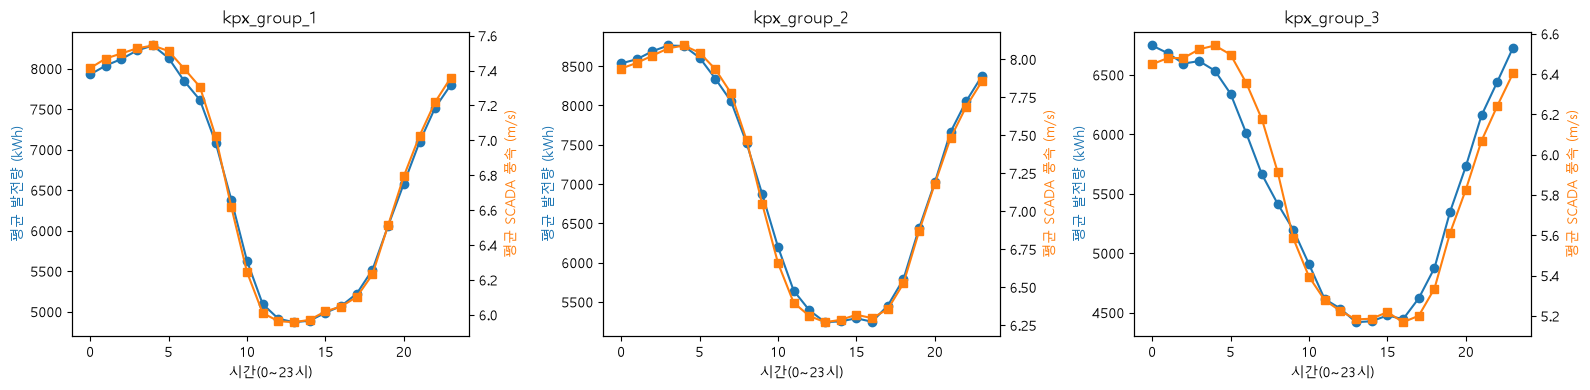

In [36]:
train_base["hour"] = train_base["kst_dtm"].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    scada_col = f"scada_ws_{group_col}"
    power_profile = train_base.groupby("hour")[group_col].mean()
    ws_profile = train_base.groupby("hour")[scada_col].mean()

    ax2 = ax.twinx()
    ax.plot(power_profile.index, power_profile.values, color="tab:blue", marker="o", label="발전량(좌측 축)")
    ax2.plot(ws_profile.index, ws_profile.values, color="tab:orange", marker="s", label="SCADA 풍속(우측 축)")
    ax.set_xlabel("시간(0~23시)")
    ax.set_ylabel("평균 발전량 (kWh)", color="tab:blue")
    ax2.set_ylabel("평균 SCADA 풍속 (m/s)", color="tab:orange")
    ax.set_title(group_col)
plt.tight_layout()
plt.show()

**확인할 것**: 주황색(풍속) 선이 파란색(발전량) 선과 같은 모양(13~16시 근처에서 같이 내려감)인지, 아니면 풍속은 평평한데 발전량만 내려가는지 알려주세요. 이게 이번 절에서 가장 중요하게 확인해야 할 질문입니다.

### 4-5. "24시간 이상 연속 0" 구간(1절에서 발견, 그룹별 7/6/6회) — curtailment인가 진짜 무풍인가

**무엇을/왜**: 1절 1-5에서 24시간 이상 계속 발전량이 0인 구간을 그룹별로 7/6/6회 찾았지만, 그때는 개수만 셌지 그 시간에 바람이 있었는지는 몰랐습니다. 이제 각 구간의 정확한 시작~끝 시각을 다시 찾고, 그 구간 동안 SCADA 풍속 평균을 확인합니다.

- 그 구간 SCADA 풍속이 컷인(대략 3 m/s) 이상인데도 0 → 터빈 정지/curtailment로 강하게 의심
- 그 구간 SCADA 풍속도 거의 0에 가까움 → 진짜 무풍(정상적인 0)

In [37]:
scada_ws_by_time = train_base.set_index("kst_dtm")[[f"scada_ws_{g}" for g in GROUP_COLS]]

for col in GROUP_COLS:
    s = labels.set_index("kst_dtm")[col].dropna()
    is_zero = s == 0
    run_id = (~is_zero).cumsum()
    zero_s = s[is_zero]
    zero_run_id = run_id[is_zero]
    print(f"--- {col} ---")
    for _, group in zero_s.groupby(zero_run_id):
        if len(group) >= 24:
            start, end = group.index.min(), group.index.max()
            ws_during = scada_ws_by_time.loc[start:end, f"scada_ws_{col}"]
            print(f"  {start} ~ {end} ({len(group)}시간) | 구간 중 SCADA 평균풍속: {ws_during.mean():.2f} m/s (결측 {ws_during.isna().sum()}건)")


--- kpx_group_1 ---
  2022-01-23 23:00:00 ~ 2022-01-25 12:00:00 (38시간) | 구간 중 SCADA 평균풍속: 5.12 m/s (결측 0건)
  2023-02-13 02:00:00 ~ 2023-02-16 14:00:00 (85시간) | 구간 중 SCADA 평균풍속: 4.95 m/s (결측 0건)
  2023-08-16 16:00:00 ~ 2023-08-17 17:00:00 (26시간) | 구간 중 SCADA 평균풍속: 1.69 m/s (결측 0건)
  2024-01-18 17:00:00 ~ 2024-01-23 16:00:00 (120시간) | 구간 중 SCADA 평균풍속: 8.15 m/s (결측 0건)
  2024-02-07 02:00:00 ~ 2024-02-08 08:00:00 (31시간) | 구간 중 SCADA 평균풍속: 4.13 m/s (결측 0건)
  2024-02-22 01:00:00 ~ 2024-02-29 01:00:00 (169시간) | 구간 중 SCADA 평균풍속: 5.43 m/s (결측 0건)
  2024-03-06 09:00:00 ~ 2024-03-07 16:00:00 (32시간) | 구간 중 SCADA 평균풍속: 4.74 m/s (결측 0건)
--- kpx_group_2 ---
  2022-01-24 02:00:00 ~ 2022-01-25 12:00:00 (35시간) | 구간 중 SCADA 평균풍속: 5.22 m/s (결측 0건)
  2022-03-18 15:00:00 ~ 2022-03-21 17:00:00 (75시간) | 구간 중 SCADA 평균풍속: 5.57 m/s (결측 0건)
  2023-02-13 03:00:00 ~ 2023-02-16 14:00:00 (84시간) | 구간 중 SCADA 평균풍속: 5.08 m/s (결측 0건)
  2024-01-18 18:00:00 ~ 2024-01-22 06:00:00 (85시간) | 구간 중 SCADA 평균풍속: 7.30 m/s (결측 0건)
 

**확인할 것**: 구간별 SCADA 평균풍속이 3 m/s를 넘는 구간이 있는지(있다면 그 날짜를 콕 집어 정지/curtailment 후보로 `03_features.ipynb`에 결측·이상치 처리 방침에 반영합니다), SCADA 자체가 결측인 구간이 있는지(2022년처럼 SCADA가 아예 없는 시기와 겹치면 판단 불가).

### 4-6. 계절×풍속 상호작용, SCADA 실측 풍속으로 재검증

**무엇을/왜**: 3-3에서 예보(LDAPS 10m 대리) 풍속 기준으로는 그룹마다 겨울/여름 차이가 들쭉날쭉했습니다(group_1은 최대 2배, group_3은 오히려 여름이 높음). 이게 진짜 공기밀도·기상 효과인지, 아니면 "10m 예보가 허브고도 풍속을 제대로 못 맞춰서" 생긴 착시인지 SCADA 실측 풍속으로 같은 분석을 반복해 확인합니다. **SCADA로 다시 그렸을 때 겨울/여름 차이가 크게 줄어든다면, 3-3의 차이는 대부분 예보의 불완전함 때문이었다는 뜻입니다.**

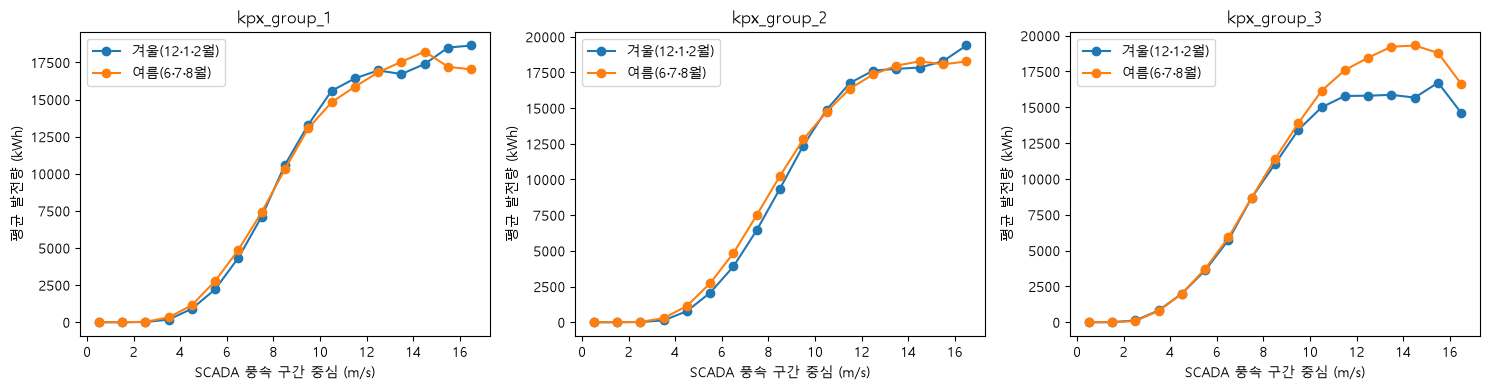

In [38]:
WS_BIN_EDGES = np.arange(0, 18, 1)
for group_col in GROUP_COLS:
    scada_col = f"scada_ws_{group_col}"
    train_base[f"{group_col}_scada_ws_bin"] = pd.cut(train_base[scada_col], WS_BIN_EDGES)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    bin_col = f"{group_col}_scada_ws_bin"
    sub = train_base.dropna(subset=["season", group_col, bin_col])
    profile = sub.groupby(["season", bin_col], observed=True)[group_col].mean().unstack("season")
    bin_centers = [interval.mid for interval in profile.index]
    ax.plot(bin_centers, profile["겨울"], marker="o", label="겨울(12·1·2월)")
    ax.plot(bin_centers, profile["여름"], marker="o", label="여름(6·7·8월)")
    ax.set_xlabel("SCADA 풍속 구간 중심 (m/s)")
    ax.set_ylabel("평균 발전량 (kWh)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

**확인할 것**: 겨울/여름 두 선이 3-3보다 훨씬 가까이 붙어 있는지(특히 group_1의 저~중풍속대). 붙어 있다면 "계절 효과는 대부분 예보 대리변수의 한계였다"고 결론 내릴 수 있고, 그래도 차이가 남아있다면 진짜 공기밀도·결빙 효과가 있다는 뜻이니 그 크기를 알려주세요.

## 5. 시간 무결성 (Time Integrity)

**왜**: 이 대회는 시계열 예측입니다. 중복된 시각이 있거나, 1시간 간격이 어딘가 깨져 있거나(예: 갑자기 2시간 건너뜀), train과 test 경계가 겹치거나 비어 있으면 — 시차(lag) 피처, 리샘플링, 검증 분리(A안/B안)가 모두 조용히 깨질 수 있습니다. 겉으로는 에러가 안 나서 더 위험합니다. 이번 절에서 세 가지를 확인합니다.

- 5-1: `kst_dtm` 중복이 없는지
- 5-2: 시간 간격이 항상 정확히 1시간인지 (한국은 서머타임(DST, 여름에 시계를 1시간 앞당기는 제도)이 없으므로 1시간 간격이 항상 균일해야 정상입니다)
- 5-3: train 마지막 시각과 test 첫 시각이 정확히 이어지는지(경계에 구멍이나 겹침이 없는지)

### 5-1. 중복 타임스탬프 확인

**무엇을**: `labels`, `train_base`, `test_base` 세 테이블 모두 `kst_dtm`에 중복이 있는지 셉니다. 중복이 있으면 groupby·merge 단계에서 행이 의도치 않게 늘어나 있었다는 뜻이라 앞 단계부터 다시 봐야 합니다.

In [39]:
for name, df in [("labels", labels), ("train_base", train_base), ("test_base", test_base)]:
    dup = df["kst_dtm"].duplicated().sum()
    print(name, "shape:", df.shape, "| 중복 kst_dtm 건수:", dup)

labels shape: (26304, 6) | 중복 kst_dtm 건수: 0
train_base shape: (26304, 827) | 중복 kst_dtm 건수: 0
test_base shape: (8760, 798) | 중복 kst_dtm 건수: 0


**확인할 것**: 세 테이블 모두 중복 건수가 0인지 확인해 주세요. 0이 아니면 바로 알려주세요 — 심각한 문제입니다.

### 5-2. 시간 간격 균일성 확인

**무엇을**: 시각을 정렬한 뒤 바로 이웃한 두 시각의 차이(간격)를 전부 계산해서, 등장하는 간격의 종류가 "1시간" 하나뿐인지 확인합니다. 여러 종류가 나오면(예: 30분, 2시간) 어딘가 시각이 밀렸거나 구멍이 있다는 뜻입니다.

In [40]:
for name, df in [("labels", labels), ("train_base", train_base), ("test_base", test_base)]:
    diffs = df["kst_dtm"].sort_values().diff().dropna()
    print(name, "등장하는 간격 종류:", diffs.unique())

labels 등장하는 간격 종류: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
train_base 등장하는 간격 종류: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
test_base 등장하는 간격 종류: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]


**확인할 것**: 세 테이블 모두 `0 days 01:00:00` 딱 하나만 나오는지 확인해 주세요. 다른 간격이 섞여 있다면 몇 건인지, 어느 시점인지 알려주세요.

### 5-3. train/test 경계 확인 (2025-01-01)

**무엇을**: train_base의 마지막 시각과 test_base의 첫 시각 사이 간격을 계산합니다. 정확히 1시간이어야 "구멍도 겹침도 없이 이어진다"는 뜻입니다. test_base의 전체 범위도 함께 확인해 정확히 2025년 한 해(8,760시간)를 커버하는지 봅니다.

In [41]:
print("train_base 범위:", train_base["kst_dtm"].min(), "~", train_base["kst_dtm"].max())
print("test_base  범위:", test_base["kst_dtm"].min(), "~", test_base["kst_dtm"].max())
gap = test_base["kst_dtm"].min() - train_base["kst_dtm"].max()
print("train 마지막 시각과 test 첫 시각의 간격:", gap)

train_base 범위: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
test_base  범위: 2025-01-01 01:00:00 ~ 2026-01-01 00:00:00
train 마지막 시각과 test 첫 시각의 간격: 0 days 01:00:00


**확인할 것**: 간격이 정확히 `0 days 01:00:00`인지(구멍도 겹침도 없음), test_base 범위가 2025-01-01 01:00부터 2026-01-01 00:00까지(1시간 단위 라벨링 관례상 이게 2025년 한 해 8,760시간 전체를 의미합니다)인지 확인해 주세요.

## 6. 추가 검증 (데이터 사이언티스트·도메인 전문가 관점 후속 확인)

1~5절 체크리스트는 다 채웠지만, 두 관점에서 다시 보니 "결론은 냈는데 근거가 얕은" 지점이 4개 있었습니다. 이번 절에서 각각 직접 계산해서 확인합니다.

- 6-1(데이터 사이언티스트): train(2022~2024)과 test(2025)의 기상 분포가 비슷한지 — 다르면 검증 점수가 실제 리더보드 성능을 잘 대표 못 할 수 있음
- 6-2(데이터 사이언티스트): 4-5에서 curtailment로 판단한 3개 구간이 사실 컷아웃(cut-out, 너무 센 바람에 터빈이 스스로 멈추는 안전장치) 때문은 아니었는지 — 그때는 평균풍속만 봤지 순간최고풍속은 안 봤습니다
- 6-3(도메인 전문가): 결빙(icing, 블레이드에 얼음이 붙어 공기역학적 효율이 떨어지는 현상)이 실제로 발전량을 낮추는지 — 3-3/4-6에서 계절 효과가 그룹마다 다르게 남아있던 것과 관련된 가설
- 6-4(도메인 전문가): 후류효과(wake effect, 앞 터빈이 바람을 가로막아 뒤 터빈이 약한 바람을 맞는 현상)가 터빈별 데이터에서 보이는지

### 6-1. train(2022~2024) vs test(2025) 기상 분포 비교

**무엇을/왜**: 지금까지 본 "연도별 drift"는 전부 **라벨(발전량)**이 2022~2024 사이에서 어떻게 다른지였습니다. 정작 **모델이 실제로 입력받는 기상 예보(GFS/LDAPS)가 2025년에는 어떤 분포인지**는 한 번도 안 봤습니다. train 시절과 완전히 다른 날씨의 해라면, 아무리 검증을 잘 설계해도(A안+B안) 2025년 리더보드 점수는 예상과 다르게 나올 수 있습니다.

In [42]:
for height, (u_suffix, v_suffix) in gfs_height_cols.items():
    speeds = [wind_speed(test_base, f"gfs_g{g}_{u_suffix}", f"gfs_g{g}_{v_suffix}") for g in range(1, 10)]
    test_base[f"gfs_ws_{height}_mean"] = pd.concat(speeds, axis=1).mean(axis=1)

ldaps_speeds = [wind_speed(test_base, f"ldaps_g{g}_heightAboveGround_10_10u", f"ldaps_g{g}_heightAboveGround_10_10v") for g in range(1, 17)]
test_base["ldaps_ws_10m_mean"] = pd.concat(ldaps_speeds, axis=1).mean(axis=1)

test_base["temp_g1_c"] = test_base["gfs_g1_heightAboveGround_2_2t"] - 273.15
train_base["temp_g1_c"] = train_base["gfs_g1_heightAboveGround_2_2t"] - 273.15

test_base[WS_COLS].describe()

,gfs_ws_10m_mean,gfs_ws_80m_mean,gfs_ws_100m_mean,gfs_ws_850hPa_mean,ldaps_ws_10m_mean
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.736640,3.947103,4.116377,8.751848,5.106558
std,1.425401,2.487259,2.644623,5.791344,2.447192
min,0.529311,0.619110,0.636445,0.517131,0.323305
25%,1.816371,2.294646,2.349626,4.045351,3.248320
50%,2.379554,3.268086,3.385037,7.367580,4.693364
75%,3.151490,4.684192,4.925332,12.541473,6.687937
max,11.663682,18.629796,19.573636,31.932218,14.174224


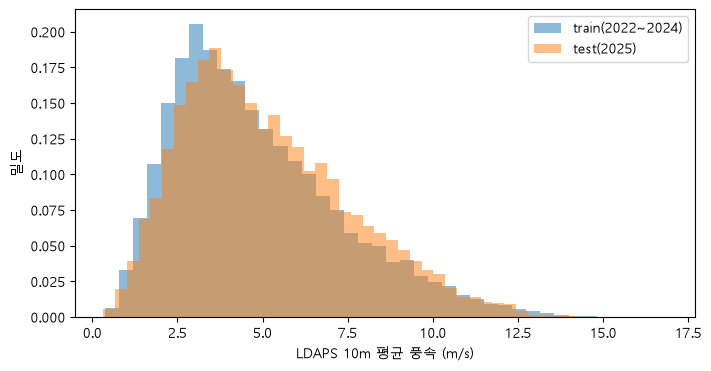

LDAPS10m 평균  train: 4.836 test: 5.107
GFS850hPa 평균 train: 8.038 test: 8.752
영하 기온 비율 train: 26.6 % test: 27.2 %


In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_base["ldaps_ws_10m_mean"], bins=40, density=True, alpha=0.5, label="train(2022~2024)")
ax.hist(test_base["ldaps_ws_10m_mean"], bins=40, density=True, alpha=0.5, label="test(2025)")
ax.set_xlabel("LDAPS 10m 평균 풍속 (m/s)")
ax.set_ylabel("밀도")
ax.legend()
plt.show()

print("LDAPS10m 평균  train:", round(train_base["ldaps_ws_10m_mean"].mean(), 3), "test:", round(test_base["ldaps_ws_10m_mean"].mean(), 3))
print("GFS850hPa 평균 train:", round(train_base["gfs_ws_850hPa_mean"].mean(), 3), "test:", round(test_base["gfs_ws_850hPa_mean"].mean(), 3))
print("영하 기온 비율 train:", round((train_base["temp_g1_c"] < 0).mean() * 100, 1), "% test:", round((test_base["temp_g1_c"] < 0).mean() * 100, 1), "%")

**확인할 것**: 두 히스토그램 모양이 크게 다른지(다르면 2025년이 이례적인 해라는 뜻), 평균 풍속·영하 비율 숫자가 train과 test에서 비슷한 수준인지 알려주세요. 완전히 같을 필요는 없지만(애초에 다른 해니까), 눈에 띄게 치우쳐 있으면(예: test가 훨씬 더 세거나 약하면) A안/B안 검증 점수를 해석할 때 감안해야 합니다.

### 6-2. curtailment 후보 구간, 컷아웃(안전정지) 재확인

**무엇을/왜**: 4-5에서 "SCADA 평균풍속이 충분한데 발전량 0"이라 curtailment로 의심한 구간들을, 이번엔 그 구간 안의 **순간 최고풍속**까지 확인합니다. 터빈은 일반적으로 풍속이 너무 세지면(통상 25 m/s 근방, 정밀 스펙 문서는 없어 참고용) 날개가 부서지는 걸 막기 위해 스스로 멈춥니다(cut-out). 평균은 낮아도 그 구간 안에 컷아웃급 돌풍이 섞여 있었다면, curtailment가 아니라 정상적인 안전 정지였을 수 있습니다.

In [44]:
def hourly_group_ws_max(df, group_map):
    """10분 단위 터빈별 풍속 -> 1시간 단위 KPX 그룹별 최고(순간) 풍속."""
    ws_cols = [c for c in df.columns if c.endswith("_ws")]
    hourly = df.set_index("kst_dtm")[ws_cols].resample("h", closed="right", label="right").max()
    group_result = {}
    for col in ws_cols:
        turbine = col.replace("_ws", "")
        group = TURBINE_GROUP_MAP[turbine]
        group_result.setdefault(group, []).append(col)
    return pd.DataFrame({group: hourly[cols].max(axis=1) for group, cols in group_result.items()})


scada_ws_max_hourly = pd.concat(
    [hourly_group_ws_max(scada_vestas_raw, TURBINE_GROUP_MAP), hourly_group_ws_max(scada_unison_raw, TURBINE_GROUP_MAP)],
    axis=1,
)
scada_ws_max_hourly = scada_ws_max_hourly.add_prefix("scada_ws_max_").reset_index()
train_base = train_base.merge(scada_ws_max_hourly, on="kst_dtm", how="left")
train_base[[f"scada_ws_max_{g}" for g in GROUP_COLS]].describe()

,scada_ws_max_kpx_group_1,scada_ws_max_kpx_group_2,scada_ws_max_kpx_group_3
count,26304.000000,26304.000000,17536.000000
mean,8.740780,9.388326,7.838773
std,4.160663,4.774854,4.290526
min,0.000000,0.000000,1.070000
25%,5.285000,5.332000,4.240000
50%,8.200000,8.500000,6.960000
75%,11.524000,12.800000,10.810000
max,27.605000,31.117000,32.050000


In [45]:
CUTOUT_GUESS = 25.0  # 일반적으로 알려진 대형 풍력터빈 컷아웃 풍속 근방(참고용, 이 터빈의 공식 스펙은 아님)

scada_ws_max_by_time = train_base.set_index("kst_dtm")[[f"scada_ws_max_{g}" for g in GROUP_COLS]]

for col in GROUP_COLS:
    s = labels.set_index("kst_dtm")[col].dropna()
    is_zero = s == 0
    run_id = (~is_zero).cumsum()
    zero_s = s[is_zero]
    zero_run_id = run_id[is_zero]
    print(f"--- {col} ---")
    for _, group in zero_s.groupby(zero_run_id):
        if len(group) >= 24:
            start, end = group.index.min(), group.index.max()
            ws_mean = scada_ws_by_time.loc[start:end, f"scada_ws_{col}"]
            ws_max = scada_ws_max_by_time.loc[start:end, f"scada_ws_max_{col}"]
            flag = " <- 컷아웃 근방 돌풍 있었음" if ws_max.max() >= CUTOUT_GUESS else ""
            print(f"  {start} ~ {end} ({len(group)}시간) | 평균풍속 {ws_mean.mean():.2f} m/s | 구간 내 최고순간풍속 {ws_max.max():.2f} m/s{flag}")

--- kpx_group_1 ---
  2022-01-23 23:00:00 ~ 2022-01-25 12:00:00 (38시간) | 평균풍속 5.12 m/s | 구간 내 최고순간풍속 10.10 m/s
  2023-02-13 02:00:00 ~ 2023-02-16 14:00:00 (85시간) | 평균풍속 4.95 m/s | 구간 내 최고순간풍속 13.03 m/s
  2023-08-16 16:00:00 ~ 2023-08-17 17:00:00 (26시간) | 평균풍속 1.69 m/s | 구간 내 최고순간풍속 3.92 m/s
  2024-01-18 17:00:00 ~ 2024-01-23 16:00:00 (120시간) | 평균풍속 8.15 m/s | 구간 내 최고순간풍속 17.83 m/s
  2024-02-07 02:00:00 ~ 2024-02-08 08:00:00 (31시간) | 평균풍속 4.13 m/s | 구간 내 최고순간풍속 8.91 m/s
  2024-02-22 01:00:00 ~ 2024-02-29 01:00:00 (169시간) | 평균풍속 5.43 m/s | 구간 내 최고순간풍속 11.33 m/s
  2024-03-06 09:00:00 ~ 2024-03-07 16:00:00 (32시간) | 평균풍속 4.74 m/s | 구간 내 최고순간풍속 7.39 m/s
--- kpx_group_2 ---
  2022-01-24 02:00:00 ~ 2022-01-25 12:00:00 (35시간) | 평균풍속 5.22 m/s | 구간 내 최고순간풍속 10.10 m/s
  2022-03-18 15:00:00 ~ 2022-03-21 17:00:00 (75시간) | 평균풍속 5.57 m/s | 구간 내 최고순간풍속 9.60 m/s
  2023-02-13 03:00:00 ~ 2023-02-16 14:00:00 (84시간) | 평균풍속 5.08 m/s | 구간 내 최고순간풍속 13.36 m/s
  2024-01-18 18:00:00 ~ 2024-01-22 06:00:00 (85시간) |

**확인할 것**: "컷아웃 근방 돌풍 있었음" 표시가 붙은 구간이 있는지 확인해 주세요. 하나도 없다면(최고풍속이 전부 25 m/s보다 훨씬 낮다면) 4절의 curtailment 결론이 더 확실해지는 것이고, 있다면 그 구간만 "안전정지"로 재분류해야 합니다.

### 6-3. 결빙(icing) 가설 검증 — 영하일 때 발전량이 실제로 낮은가

**무엇을/왜**: 3-3/4-6에서 계절 효과가 SCADA로는 대부분 사라졌지만, 완전히 0은 아니었습니다. "겨울 = 기온이 낮음 = 블레이드에 얼음이 붙어(결빙) 공기역학적 효율이 떨어짐"이라는 가설을 세워뒀는데, 계절(월) 대신 **기온이 실제로 영하인지**를 기준으로 다시 나눠보면 더 정확하게 검증할 수 있습니다. 4-6에서 만든 SCADA 풍속 구간(`_scada_ws_bin`)을 그대로 재사용합니다.

In [46]:
for group_col, grid_id in GROUP_NEAREST_LDAPS.items():
    temp_col = f"ldaps_g{grid_id}_heightAboveGround_2_t"
    train_base[f"{group_col}_freezing"] = train_base[temp_col] < 273.15  # 0도(섭씨) 미만

for group_col in GROUP_COLS:
    ratio = train_base[f"{group_col}_freezing"].mean() * 100
    print(group_col, f"영하 시간 비율: {ratio:.1f}%")

kpx_group_1 영하 시간 비율: 28.6%
kpx_group_2 영하 시간 비율: 28.3%
kpx_group_3 영하 시간 비율: 27.6%


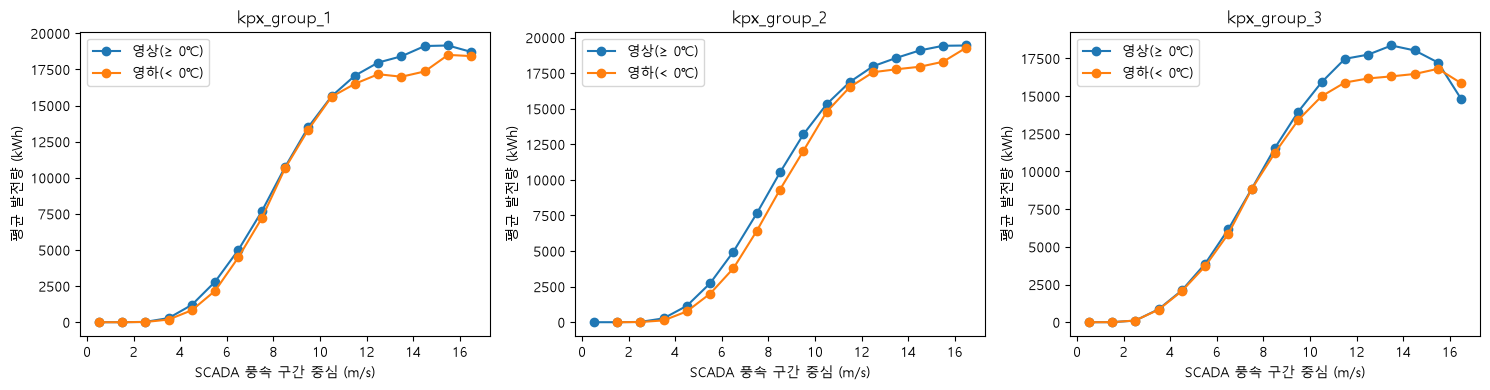

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_col in zip(axes, GROUP_COLS):
    bin_col = f"{group_col}_scada_ws_bin"
    freeze_col = f"{group_col}_freezing"
    sub = train_base.dropna(subset=[group_col, bin_col, freeze_col])
    profile = sub.groupby([freeze_col, bin_col], observed=True)[group_col].mean().unstack(freeze_col)
    bin_centers = [interval.mid for interval in profile.index]
    ax.plot(bin_centers, profile[False], marker="o", label="영상(≥ 0℃)")
    ax.plot(bin_centers, profile[True], marker="o", label="영하(< 0℃)")
    ax.set_xlabel("SCADA 풍속 구간 중심 (m/s)")
    ax.set_ylabel("평균 발전량 (kWh)")
    ax.set_title(group_col)
    ax.legend()
plt.tight_layout()
plt.show()

**확인할 것**: 저~중풍속 구간(3~8 m/s)에서 영하 선이 영상 선보다 뚜렷이 아래에 있는지, 그 차이가 group_1/2(VESTAS)와 group_3(UNISON)에서 다르게 나타나는지 알려주세요. 아래에 있고 고풍속으로 갈수록 차이가 줄어드는 모양이면 결빙 효과의 전형적인 패턴(저풍속=날개가 천천히 돌아 얼음이 잘 안 떨어짐, 고풍속=이미 정격 근처라 효율 손실이 상대적으로 작음)과 일치합니다.

### 6-4. 후류효과(wake effect) 탐색 — group_1(VESTAS 1~6호기) 예시

**무엇을/왜**: 지금까지는 그룹 평균 풍속만 봤는데, SCADA는 터빈별 풍속·풍향이 따로 있습니다. 앞 터빈이 바람을 가로막으면 뒤 터빈은 같은 시각에도 더 약하고 흐트러진 바람을 맞습니다(후류효과, wake effect). 터빈마다 풍향별 평균 풍속을 따로 그려서, 특정 방위에서 유독 풍속이 낮게 나오는 터빈이 있는지 봅니다 — 있다면 그 방위 쪽에 다른 터빈이 있다는 뜻입니다(2-1의 지도와 대조해서 확인 가능).

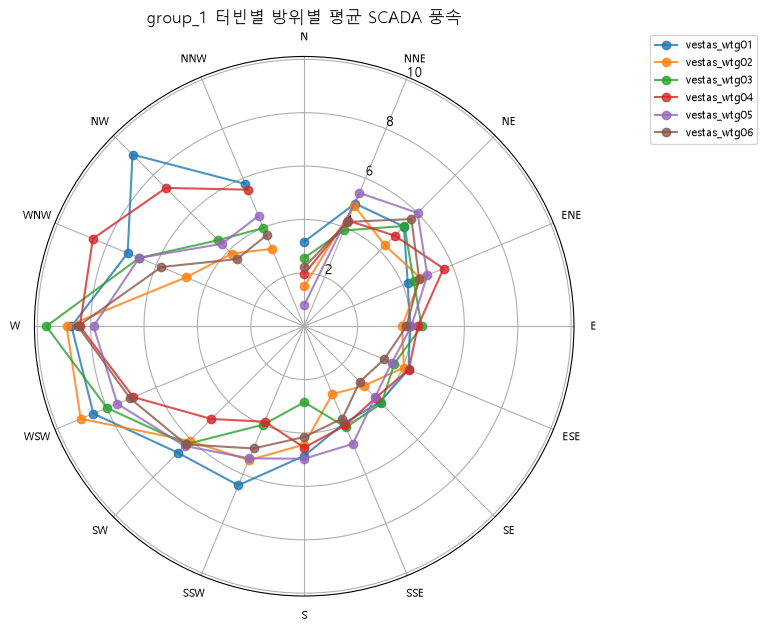

In [48]:
GROUP1_TURBINES = [f"vestas_wtg{i:02d}" for i in range(1, 7)]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
angles = np.deg2rad(np.arange(0, 360, 22.5))
for turbine in GROUP1_TURBINES:
    sector = scada_vestas_raw[f"{turbine}_wd"].apply(to_16_sector)
    profile = scada_vestas_raw.groupby(sector)[f"{turbine}_ws"].mean().reindex(DIRECTIONS_16)
    ax.plot(angles, profile.values, marker="o", label=turbine, alpha=0.8)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(DIRECTIONS_16, fontsize=8)
ax.legend(bbox_to_anchor=(1.35, 1.05), fontsize=8)
ax.set_title("group_1 터빈별 방위별 평균 SCADA 풍속")
plt.tight_layout()
plt.show()

**확인할 것**: 6개 선이 대부분 방위에서는 비슷하게 움직이다가, 특정 방위 1~2곳에서만 유독 갈라지는(어떤 터빈만 뚝 떨어지는) 구간이 있는지 봐주세요. 있다면 어느 터빈이 어느 방위에서 낮은지 알려주시면, 2-1의 격자 지도(터빈 위치)와 대조해서 실제로 그 방향에 다른 터빈이 있는지 확인해보겠습니다.

## 요약 및 다음 단계

이번 배치에서는 6절(데이터 사이언티스트·도메인 전문가 관점 후속 검증 — train/test 기상 분포 비교, 컷아웃 재확인, 결빙 가설, 후류효과)을 추가했습니다. 이걸로 EDA를 마무리합니다.

**실행 방법**: 6절 셀을 위에서부터 순서대로 실행해 주시고, 각 '확인할 것' 항목의 실제 값을 알려주세요. 확인되면:
1. `reports/02_eda.md`에 6절 결과를 이어서 정리하고 EDA 전체를 마무리
2. `preprocessing`/`wind-domain-features` 스킬로 넘어가 지금까지 쌓인 결정 사항(HANDOFF.md 참고)을 `03_features.ipynb`에 반영하겠습니다.